# Optimal control 

In [44]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import sys
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [45]:
new_red = (243/255, 114/255, 82/255)
new_orange = (252/255, 180/255, 97/255)
new_green = (127/255, 198/255, 211/255)
new_purple = (111/255, 120/255, 185/255)

new_green1 = (150/255, 184/255, 155/255)
new_green2 = (171/255, 224/255, 228/255)
new_green = (127/255, 198/255, 211/255)
new_green4 = (119/255, 159/255, 198/255)

TEXT = "sto_sensitivity"


In [46]:
alpha_act_range = np.array([
    0.0126,0.0132,0.0141,0.0151,0.0158,0.0166,0.0174,0.0179,0.0187,0.0195,0.0201,
    0.0206,0.0217,0.0227,0.0236,0.0248,0.0259,0.0266,0.0268,0.0273,0.0271,0.0268,
    0.0264,0.0258,0.0252,0.0244,0.024,0.0211,0.0211,0.0207])

p1_act_range = np.array([
    0.0047,0.0047,0.0040,0.0033,0.0036,0.0035,0.0035,0.0033,0.0029,0.0039,0.0034,
    0.0038,0.0036,0.0034,0.0032,0.0035,0.0026,0.0027,0.0020,0.0024,0.0020,0.0024,
    0.0019,0.0026,0.0025,0.0024,0.0026,0.0031,0.0029,0.0029])


k0 =  0.006
k1 = -0.1341

def p1fn(alpha):
    return k0 + k1 * alpha

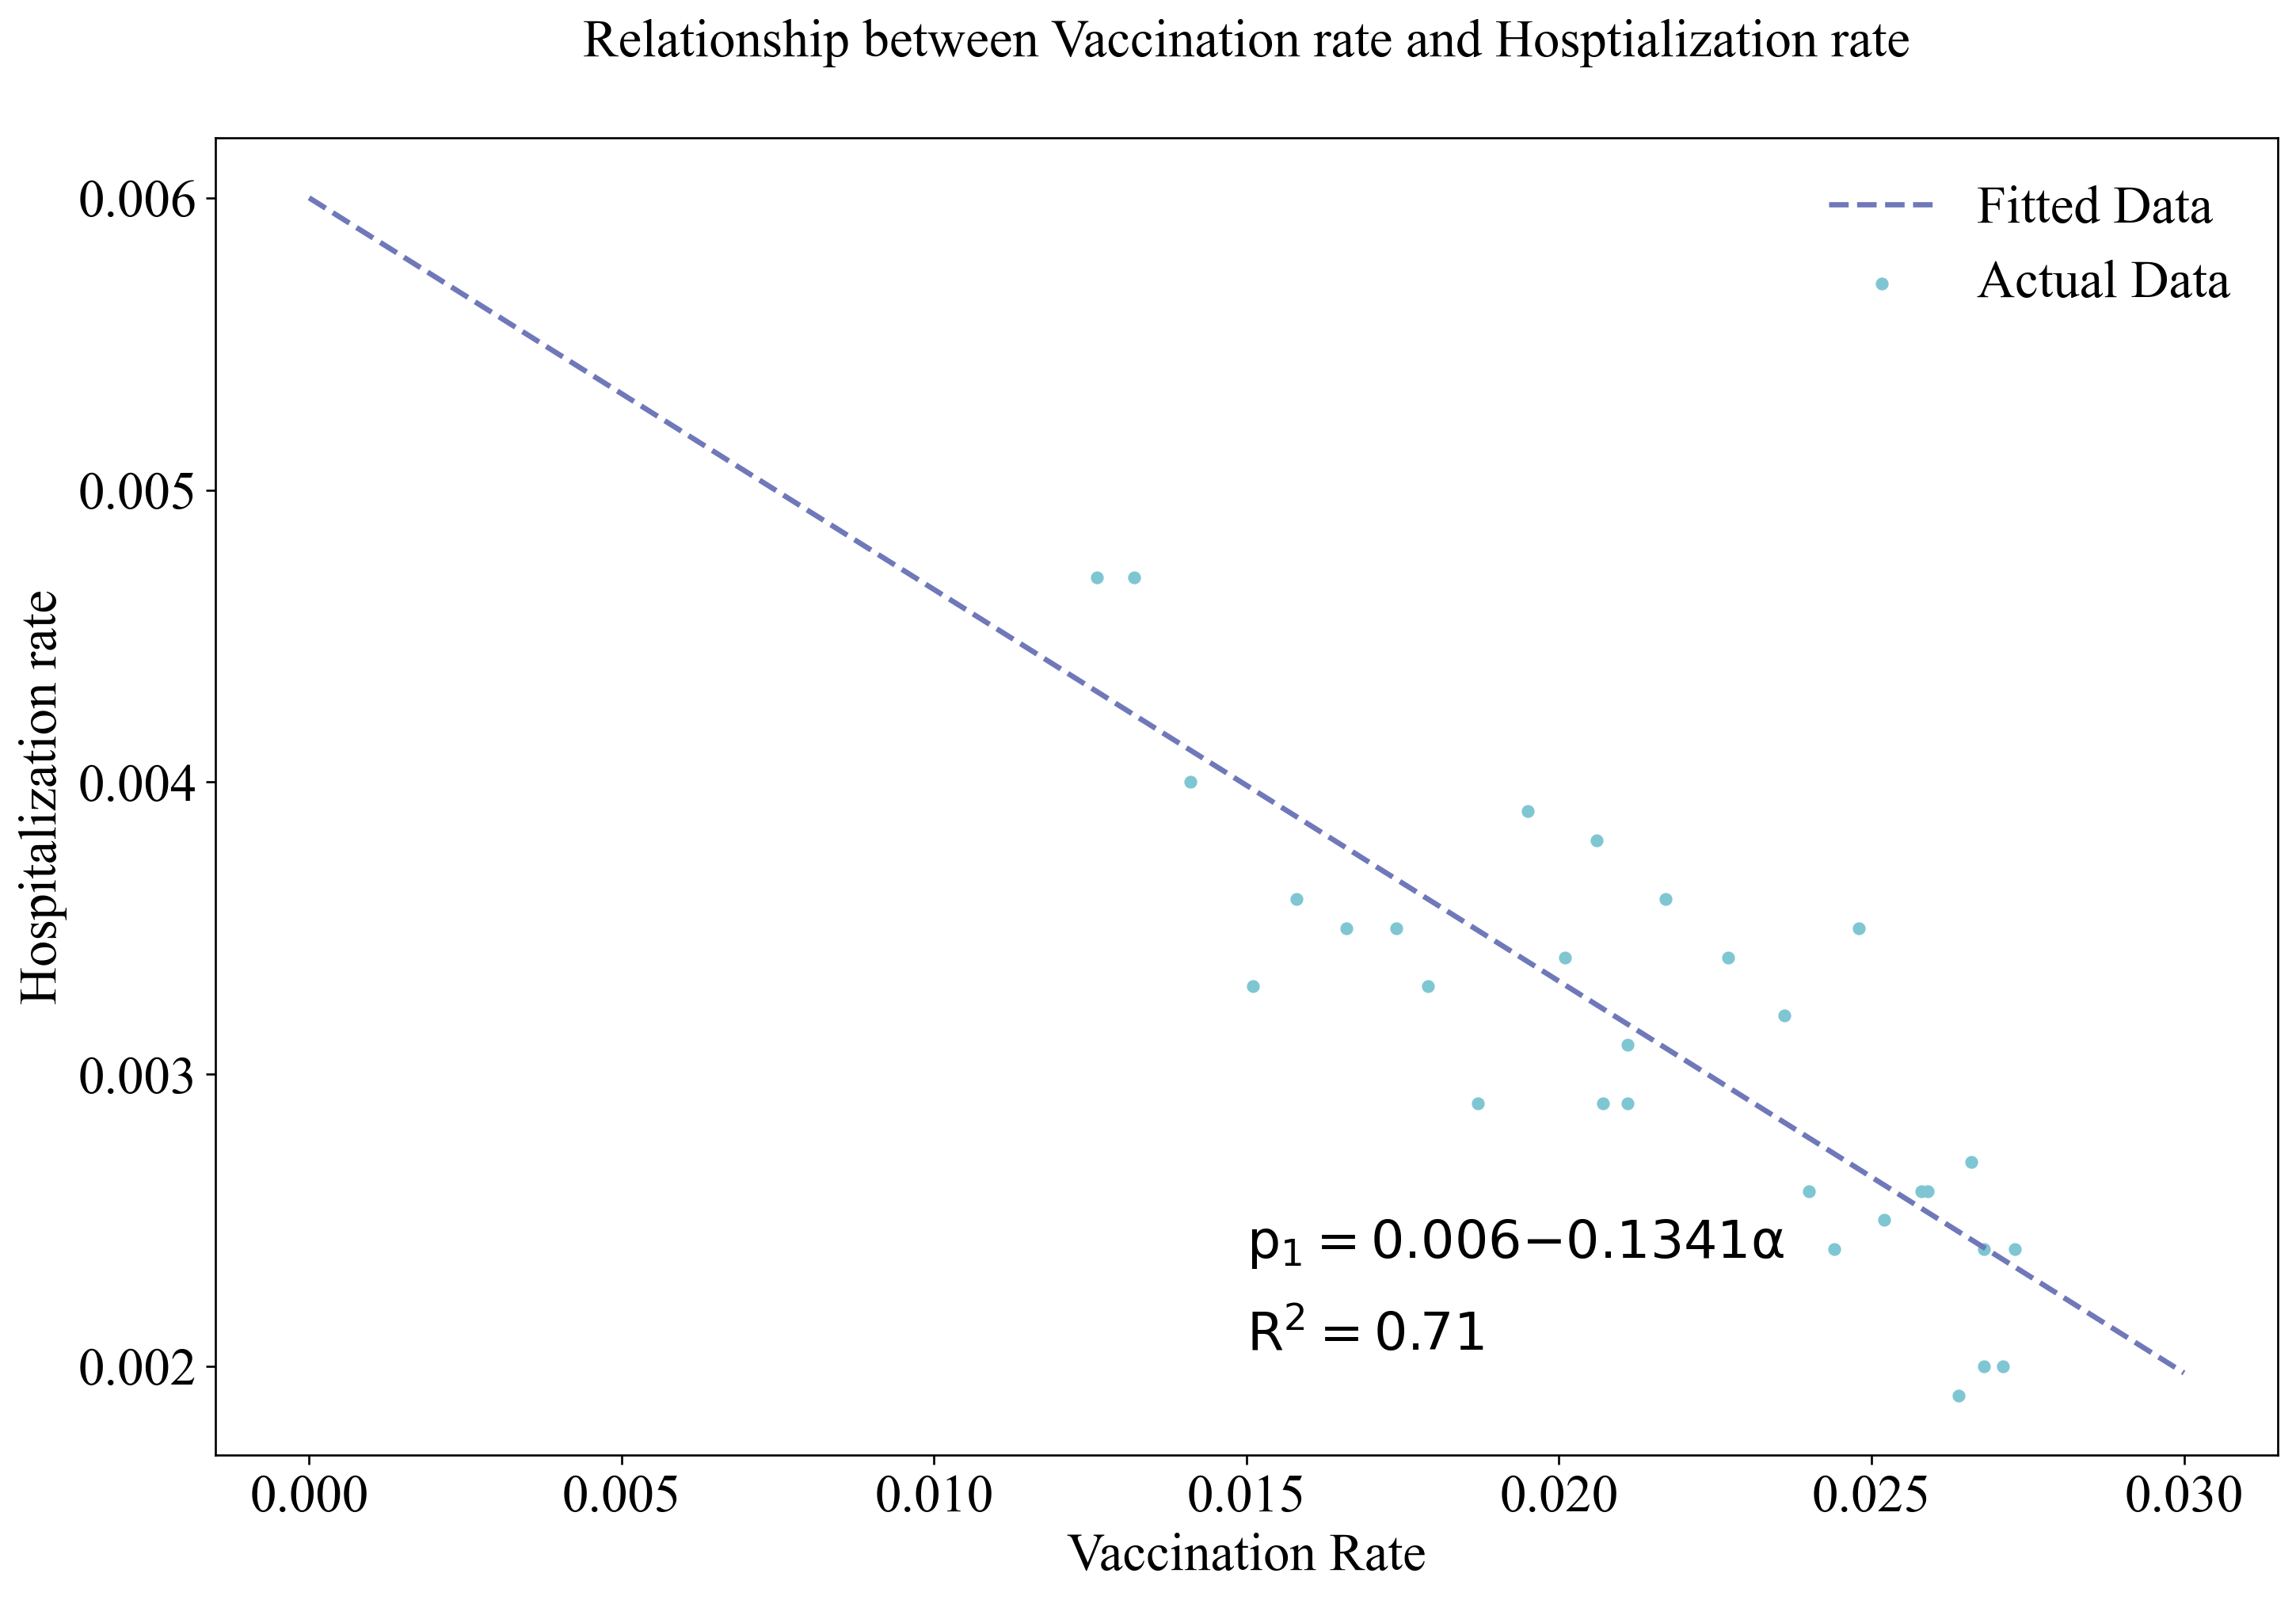

In [47]:
y_pred = p1fn(alpha_act_range)
r2 = r2_score(p1_act_range, y_pred)

t_domain = np.linspace(0, 0.03, len(alpha_act_range))
fig, ax0 = plt.subplots(1, 1, figsize =(14, 9), dpi = 240, sharey = True)

ax0.scatter(alpha_act_range, p1_act_range, s=15, color=new_green, marker='o')  
ax0.plot(t_domain, p1fn(t_domain), lw = 2, ls = '--', color = new_purple, label = 'Optimal vaccination rate')
ax0.set_xlabel('Vaccination Rate', fontsize = 20, family='Times New Roman')
ax0.set_ylabel('Hospitalization rate', fontsize = 20, family='Times New Roman')
ax0.set_title('Relationship between Vaccination rate and Hosptialization rate', fontsize = 20,  y=1.05)
ax0.tick_params(axis='both', which='major', labelsize=20)
equation = r'$\mathrm{p_1} = 0.006 − 0.1341 \mathrm{\alpha}$' 
r2_text = f'$\mathrm{{R}}^2 = {r2:.2f}$'
ax0.text(0.5, 0.15, equation, color='black', fontsize=20, 
         family='Times New Roman', transform=ax0.transAxes)
ax0.text(0.5, 0.08, r2_text, color='black', fontsize=20, 
         family='Times New Roman', transform=ax0.transAxes)

#ax0.text(0.5, 0.1, equation + '\n\n' + r2_text, color='black', fontsize=20, family='Times New Roman', transform=ax0.transAxes)


ax0.legend(['Fitted Data',r'Actual Data'], frameon=False,loc='upper right', fontsize=20)
plt.rc('font', family='Times New Roman')
#plt.tight_layout()
plt.show()
#plt.savefig('D_popn_change.png')

In [48]:
u_opt = np.array([
    0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0277,0.0276,0.0276,0.0275,0.0274,
    0.0272,0.0272,0.0271,0.0269,0.0267,0.0264,0.0261,0.0257,0.0256,0.0253,0.0248,0.0243,
    0.0239,0.0236,0.0228,0.0224,0.0218,0.0211,0.0206,0.0197,0.0191,0.0184,0.0177,0.0172,
    0.0165,0.0155,0.0147,0.0139,0.0135,0.0128,0.0120,0.0114,0.0106,0.0098,0.0090,0.0082,
    0.0071,0.0063,0.0057,0.0052,0.0048,0.0045,0.0044,0.0043,0.0043,0.0042,0.0042,0.0042])

In [49]:
u_act = np.array([
    0.0126,0.0132,0.0141,0.0151,0.0158,0.0166,0.0174,0.0179,0.0187,0.0195,0.0201,0.0206,
    0.0217,0.0227,0.0236,0.0248,0.0259,0.0266,0.0268,0.0273,0.0271,0.0268,0.0264,0.0258,
    0.0252,0.0244,0.0240,0.0211,0.0211,0.0207,0.0203,0.0195,0.0190,0.0179,0.0194,0.0182,
    0.0173,0.0164,0.0158,0.0154,0.0148,0.0141,0.0135,0.0127,0.0116,0.0111,0.0106,0.0108,
    0.0101,0.0097,0.0093,0.0091,0.0086,0.0087,0.0074,0.0070,0.0064,0.0057,0.0050,0.0048]) 

In [50]:
u_constant = np.average(u_act)
u_con = np.repeat(u_constant, len(u_opt))
u_no_vacc = np.repeat(0, len(u_opt))

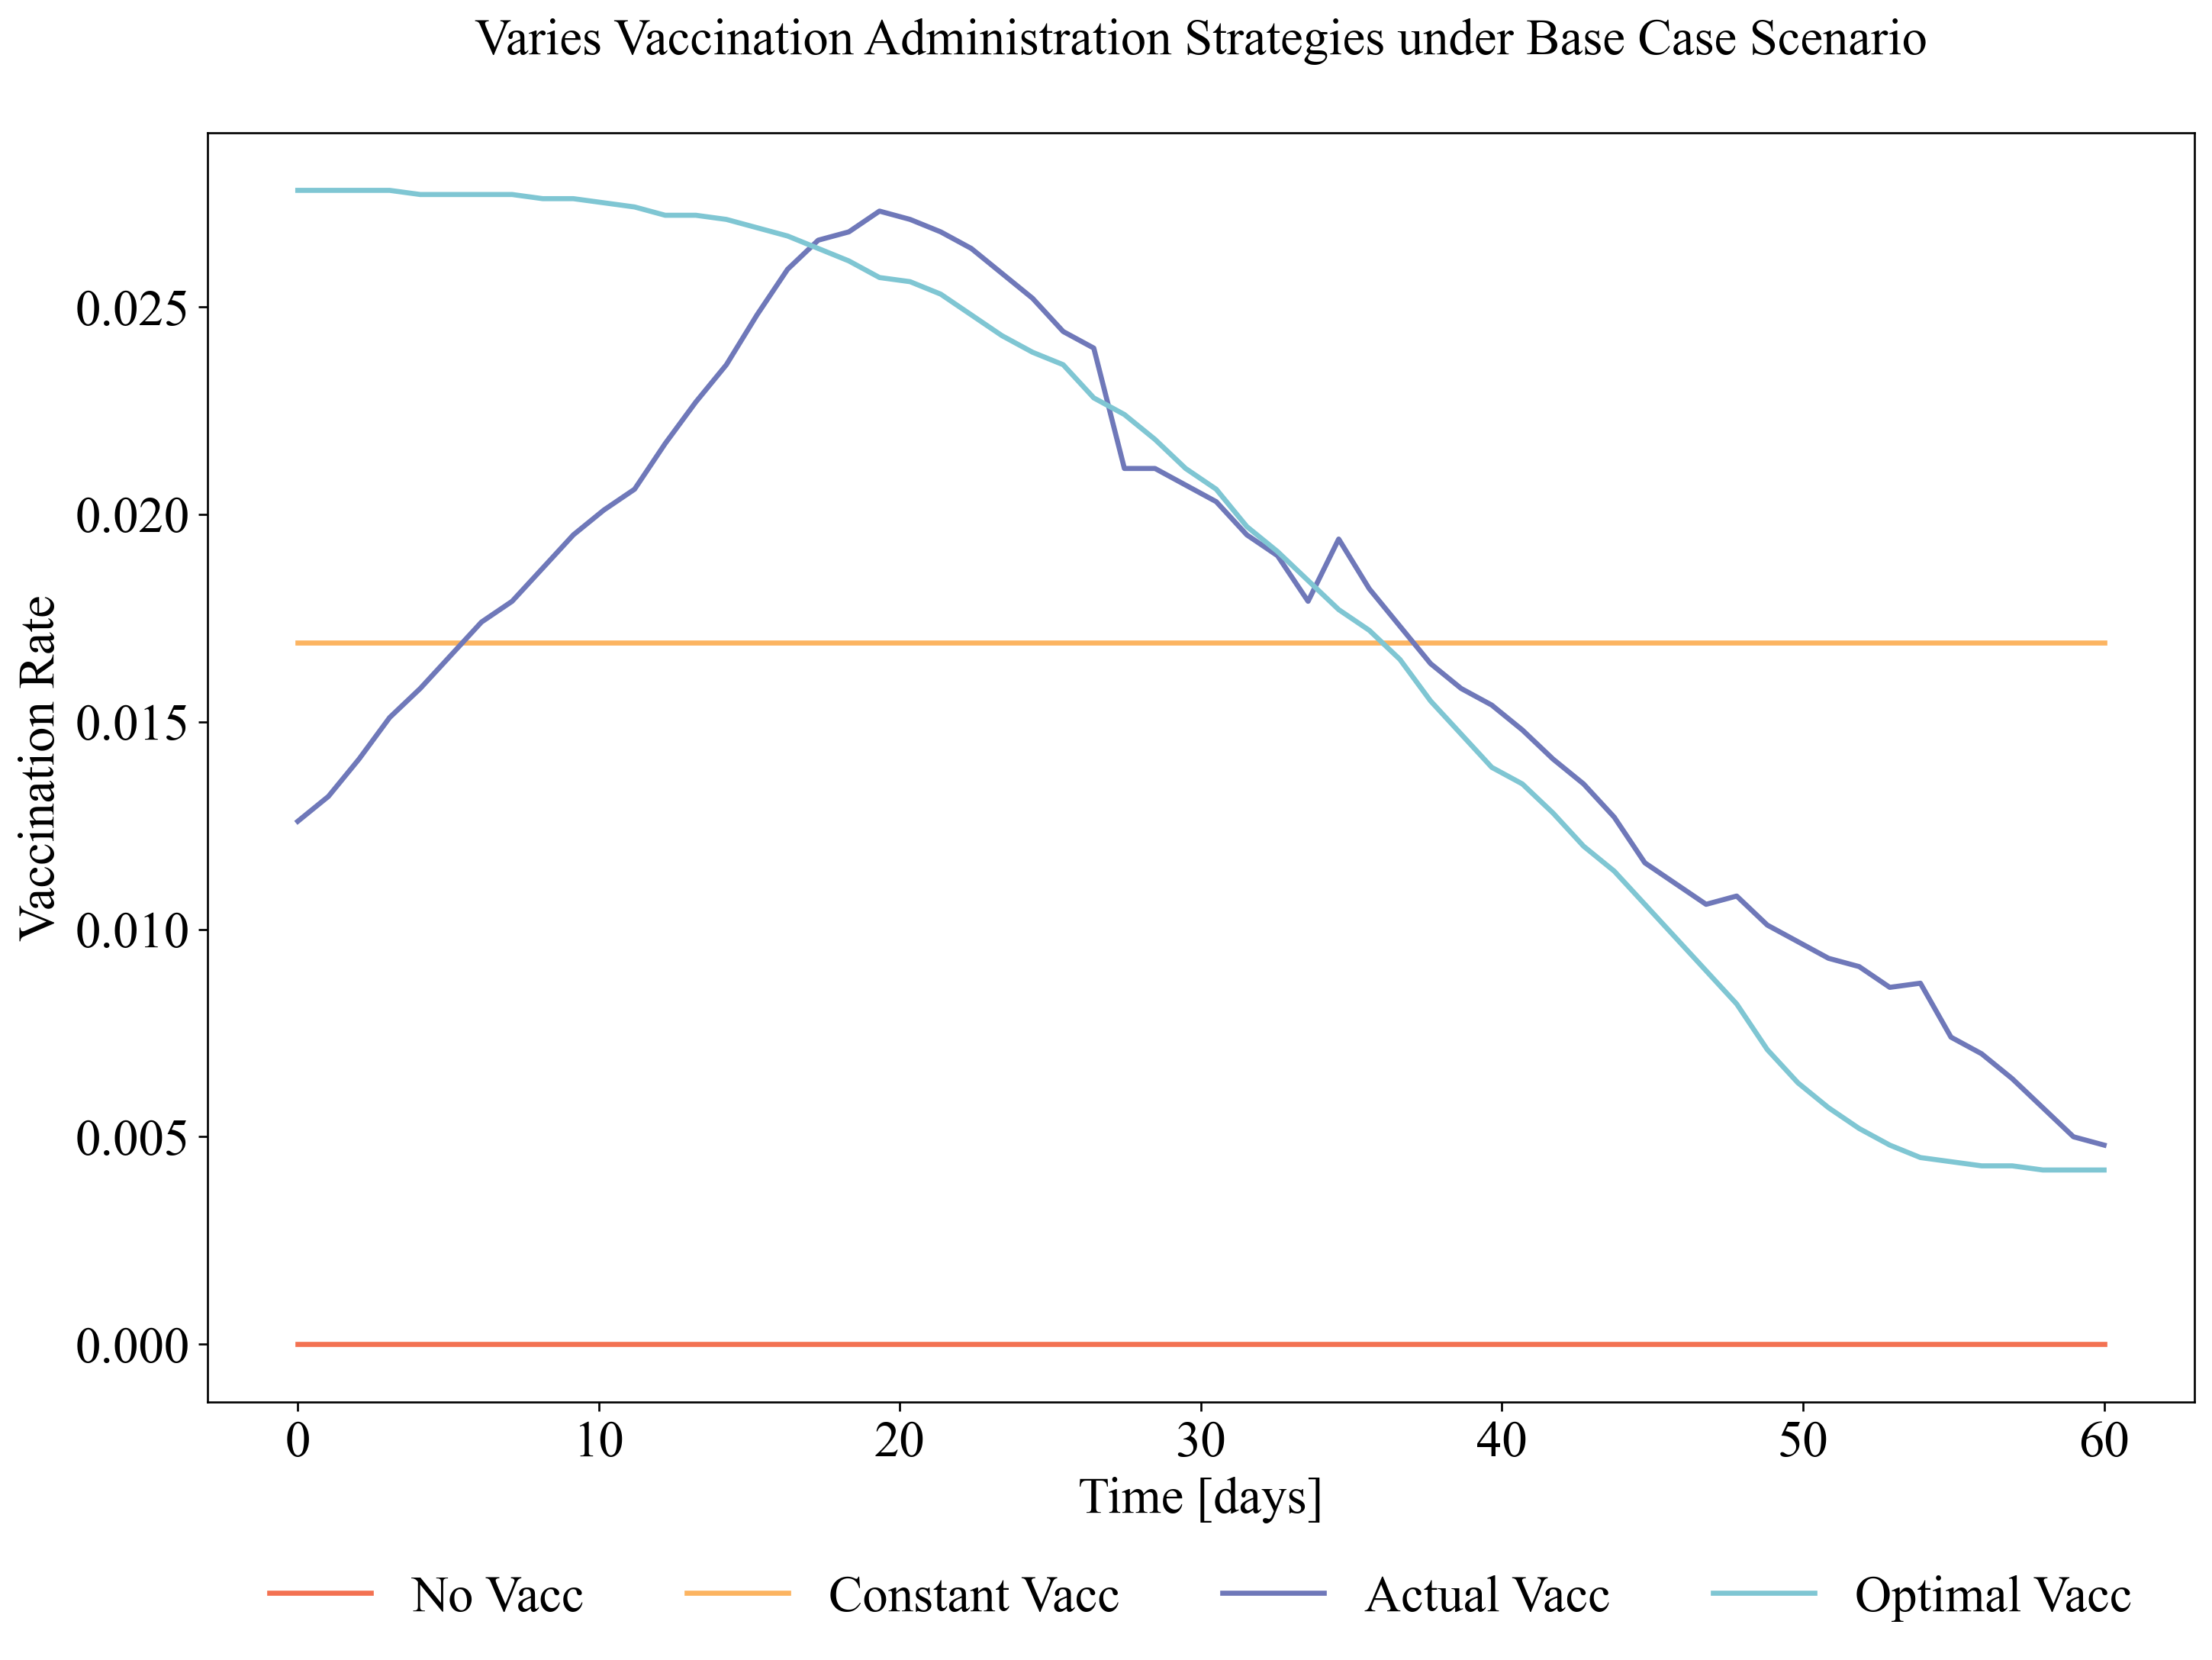

In [51]:
t_axis = np.linspace(0, len(u_opt), len(u_opt))
fig, ax0 = plt.subplots(1, 1, figsize =(14, 9), dpi = 240, sharey = True)

ax0.plot(t_axis, u_no_vacc, lw = 2, color = new_red, label = 'No Vacc')
ax0.plot(t_axis, u_con, lw = 2, color = new_orange, label = 'Constant Vacc')
ax0.plot(t_axis, u_act, lw = 2, color = new_purple, label = 'Actual Vacc')
ax0.plot(t_axis, u_opt, lw = 2, color = new_green, label = 'Optimal Vacc')

ax0.set_xlabel('Time [days]', fontsize=20, family='Times New Roman')
ax0.set_ylabel('Vaccination Rate', fontsize=20, family='Times New Roman')
ax0.set_title('Varies Vaccination Administration Strategies under Base Case Scenario', fontsize=20,  y=1.05) 
ax0.tick_params(axis='both', which='major', labelsize=20)

#ax0.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
ax0.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, fontsize=20)
plt.rc('font', family='Times New Roman')
#plt.tight_layout()
plt.show()


### Different Noise

In [52]:
u_tiny_noise = np.array([
    0.0278,0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0276,0.0276,0.0275,
    0.0274,0.0273,0.0271,0.0269,0.0266,0.0260,0.0253,0.0248,0.0235,0.0227,0.0214,
    0.0201,0.0187,0.0171,0.0156,0.0141,0.0127,0.0115,0.0103,0.0094,0.0087,0.0077,
    0.0072,0.0066,0.0061,0.0057,0.0053,0.0051,0.0049,0.0047,0.0046,0.0045,0.0045,
    0.0044,0.0044,0.0043,0.0043,0.0043,0.0043,0.0043,0.0043,0.0043,0.0042,0.0042,
    0.0042,0.0042,0.0042,0.0042,0.0042])

u_small_noise = np.array([
    0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0277,0.0276,0.0276,0.0276,
    0.0275,0.0274,0.0273,0.0273,0.0271,0.0269,0.0267,0.0266,0.0262,0.0261,0.0258,
    0.0254,0.0248,0.0245,0.0239,0.0231,0.0224,0.0217,0.0209,0.0200,0.0190,0.0182,
    0.0171,0.0161,0.0153,0.0142,0.0130,0.0120,0.0110,0.0101,0.0092,0.0084,0.0076,
    0.0070,0.0064,0.0058,0.0054,0.0050,0.0048,0.0046,0.0045,0.0044,0.0043,0.0043,
    0.0043,0.0042,0.0042,0.0042,0.0042])

u_large_noise = np.array([
    0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0276,0.0275,0.0274,0.0273,
    0.0271,0.0268,0.0265,0.0264,0.0259,0.0258,0.0253,0.0248,0.0246,0.0243,0.0238,
    0.0232,0.0227,0.0223,0.0223,0.0216,0.0212,0.0207,0.0200,0.0197,0.0192,0.0186,
    0.0182,0.0173,0.0171,0.0167,0.0162,0.0155,0.0147,0.0146,0.0143,0.0136,0.0131,
    0.0125,0.0116,0.0108,0.0102,0.0093,0.0087,0.0078,0.007,0.0062,0.0054,0.0047,
    0.0044,0.0043,0.0042,0.0042,0.0042])

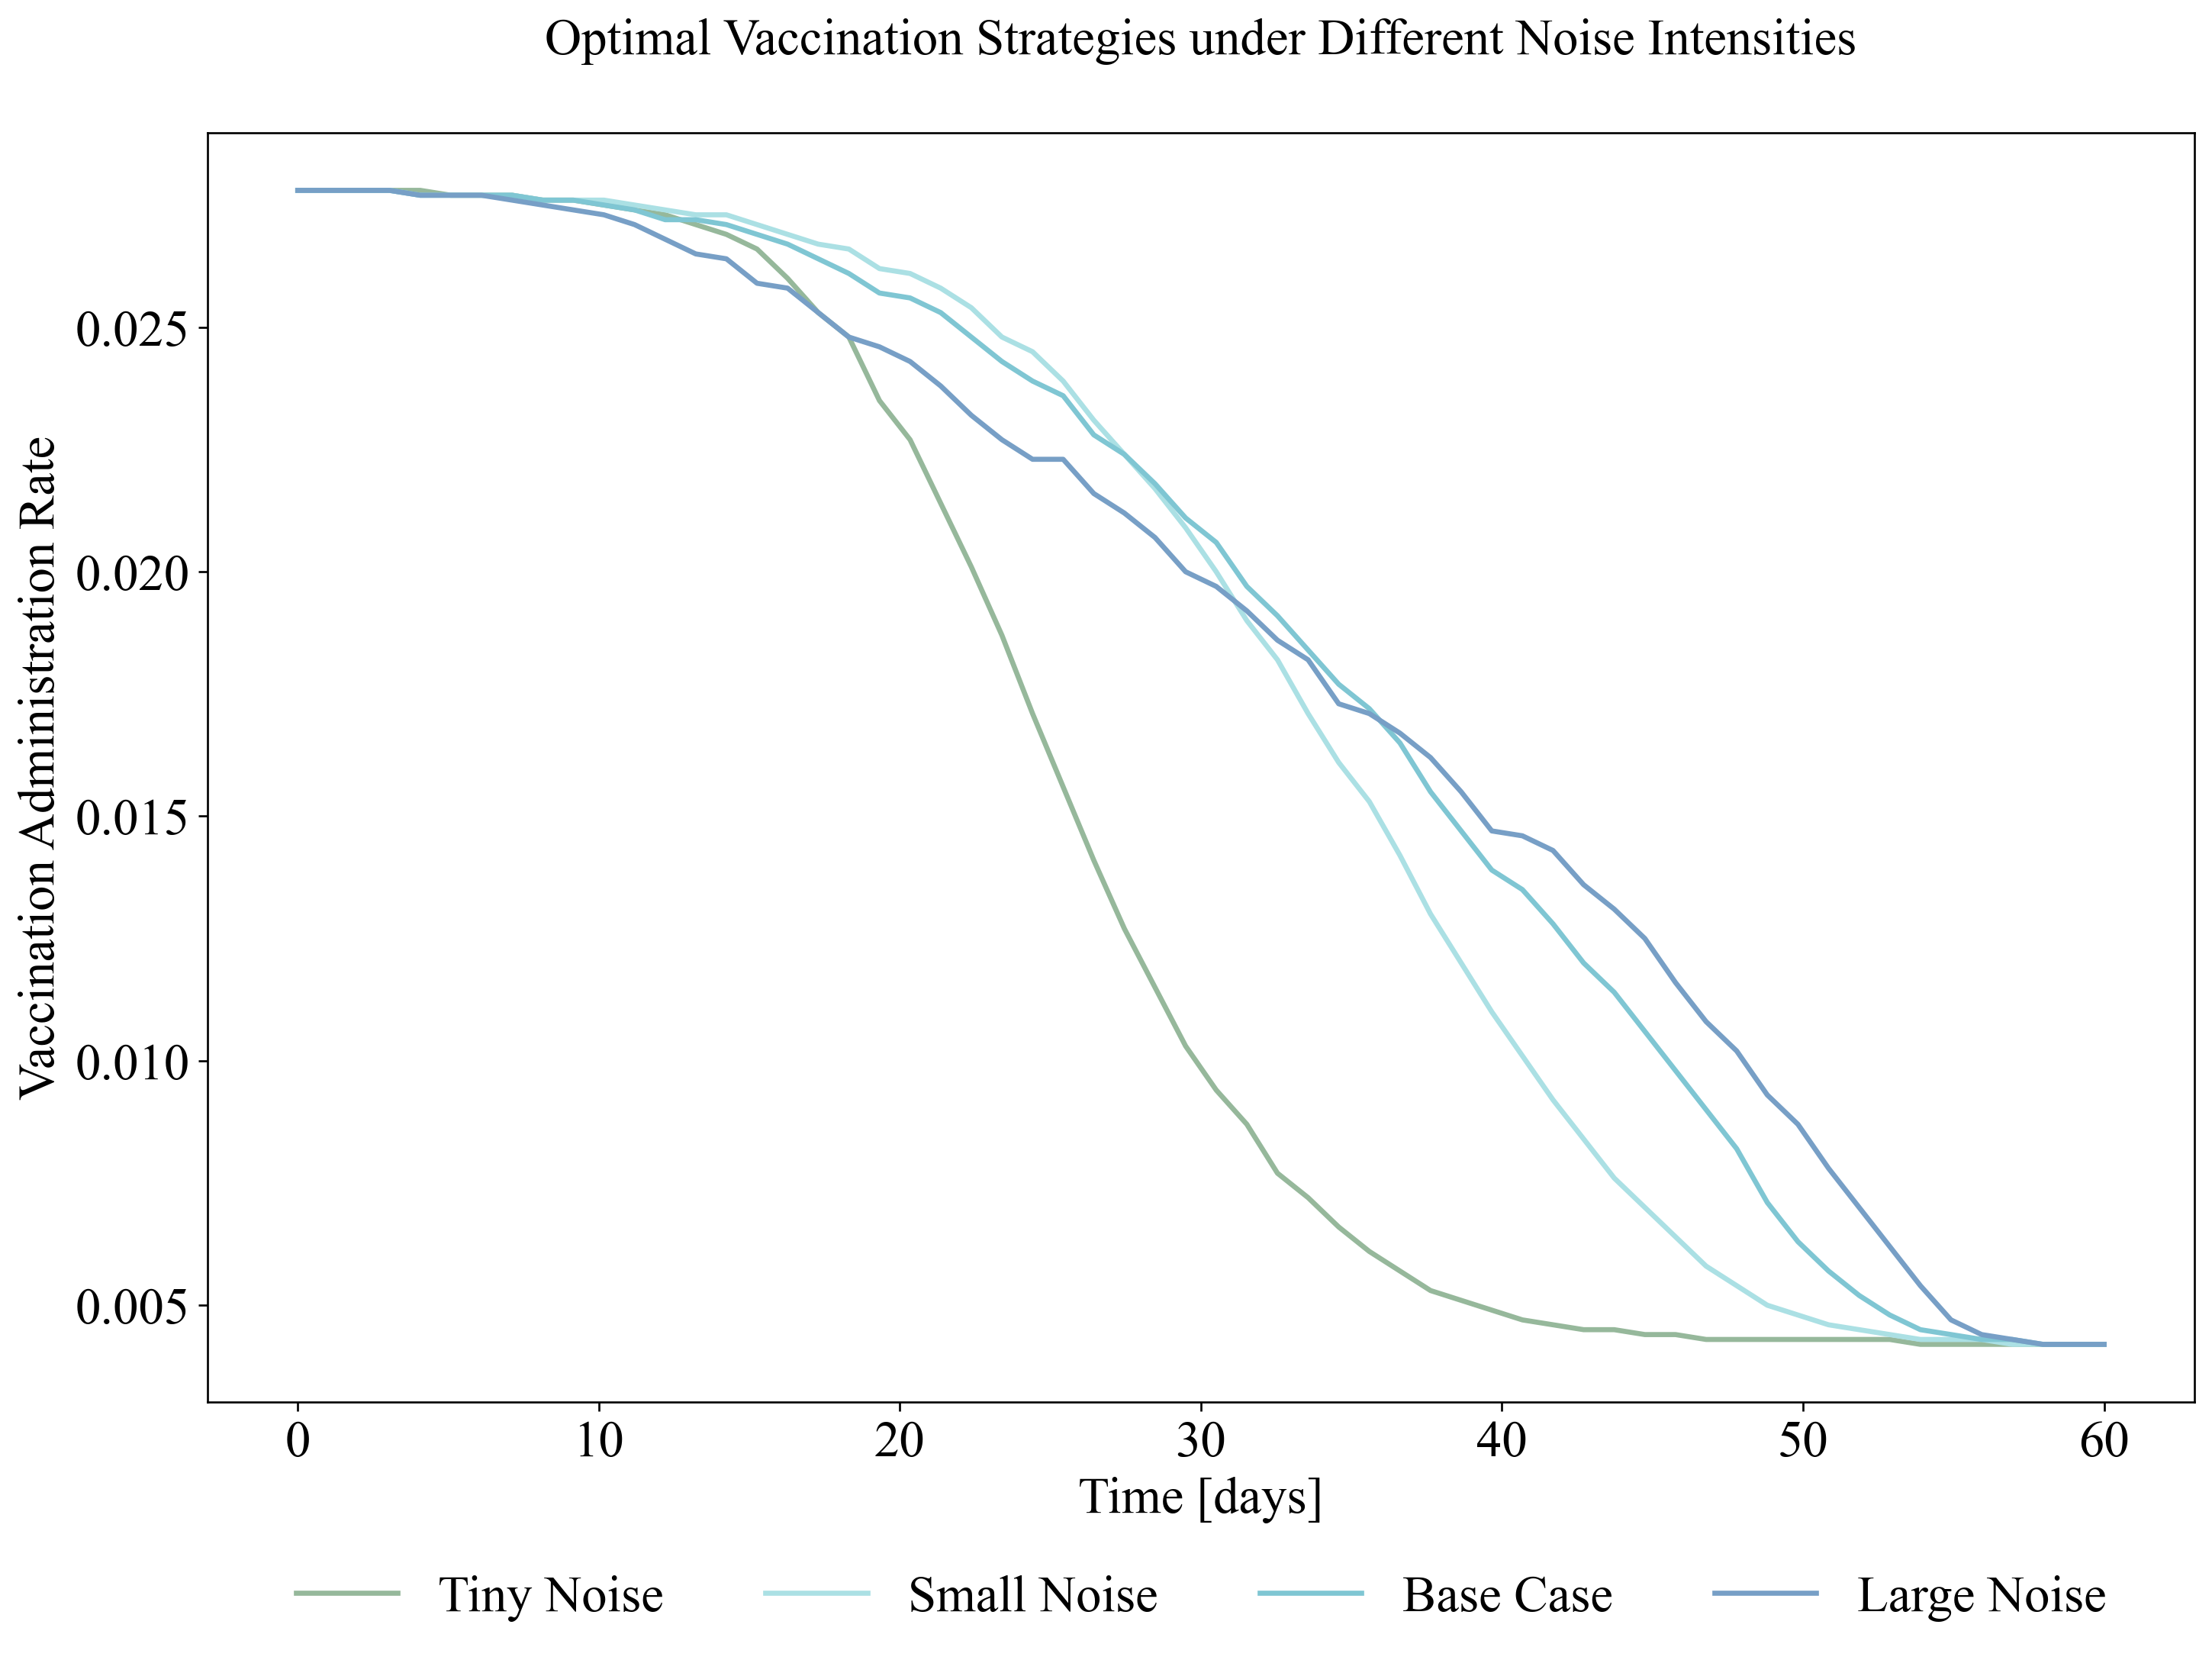

In [53]:
t_axis = np.linspace(0, len(u_opt), len(u_opt))
fig, ax0 = plt.subplots(1, 1, figsize =(14, 9), dpi = 240, sharey = True)

ax0.plot(t_axis, u_tiny_noise, lw = 2, color = new_green1, label = 'Tiny Noise')
ax0.plot(t_axis, u_small_noise, lw = 2, color = new_green2, label = 'Small Noise')
ax0.plot(t_axis, u_opt, lw = 2, color = new_green, label = 'Base Case')
ax0.plot(t_axis, u_large_noise, lw = 2, color = new_green4, label = 'Large Noise')
ax0.set_xlabel('Time [days]', fontsize=20, family='Times New Roman')
ax0.set_ylabel('Vaccination Administration Rate', fontsize=20, family='Times New Roman')
ax0.set_title('Optimal Vaccination Strategies under Different Noise Intensities', fontsize=20,  y=1.05) 
ax0.tick_params(axis='both', which='major', labelsize=20)

#ax0.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
ax0.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, fontsize=20)
plt.rc('font', family='Times New Roman')
#plt.tight_layout()
plt.show()

### Different Economic Cost

In [54]:
u_tiny_econ_cost = np.array([
    0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0276,0.0275,0.0273,0.0271,
    0.0267,0.0263,0.0258,0.0252,0.0246,0.0239,0.0230,0.0220,0.0210,0.0200,0.0190,
    0.0178,0.0167,0.0157,0.0144,0.0134,0.0124,0.0114,0.0107,0.0098,0.0092,0.0086,
    0.0080,0.0075,0.0070,0.0065,0.0061,0.0058,0.0056,0.0053,0.0050,0.0049,0.0046,
    0.0045,0.0044,0.0044,0.0043,0.0043,0.0043,0.0043,0.0043,0.0043,0.0042,0.0042,
    0.0042,0.0042,0.0042,0.0042,0.0042])

u_small_econ_cost = np.array([
    0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0277,0.0276,0.0276,0.0275,
    0.0274,0.0272,0.0271,0.0269,0.0267,0.0265,0.0261,0.0257,0.0252,0.0250,0.0246,
    0.0239,0.0233,0.0227,0.0224,0.0213,0.0206,0.0199,0.0191,0.0184,0.0175,0.0167,
    0.0162,0.0152,0.0145,0.0138,0.0126,0.0120,0.0109,0.0104,0.0096,0.0088,0.0083,
    0.0077,0.0071,0.0064,0.0059,0.0053,0.0049,0.0046,0.0045,0.0044,0.0043,0.0043,
    0.0043,0.0042,0.0042,0.0042,0.0042])

u_large_econ_cost = np.array([
    0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0277,0.0276,0.0276,0.0275,
    0.0274,0.0273,0.0272,0.0271,0.0269,0.0268,0.0265,0.0263,0.0259,0.0258,0.0256,
    0.0252,0.0248,0.0245,0.0242,0.0235,0.0233,0.0228,0.0222,0.0217,0.0210,0.0205,
    0.0198,0.0193,0.0189,0.0183,0.0176,0.0169,0.0164,0.0160,0.0154,0.0148,0.0144,
    0.0135,0.0127,0.0122,0.0114,0.0102,0.0090,0.0080,0.0071,0.0062,0.0054,0.0048,
    0.0045,0.0043,0.0043,0.0042,0.0042])

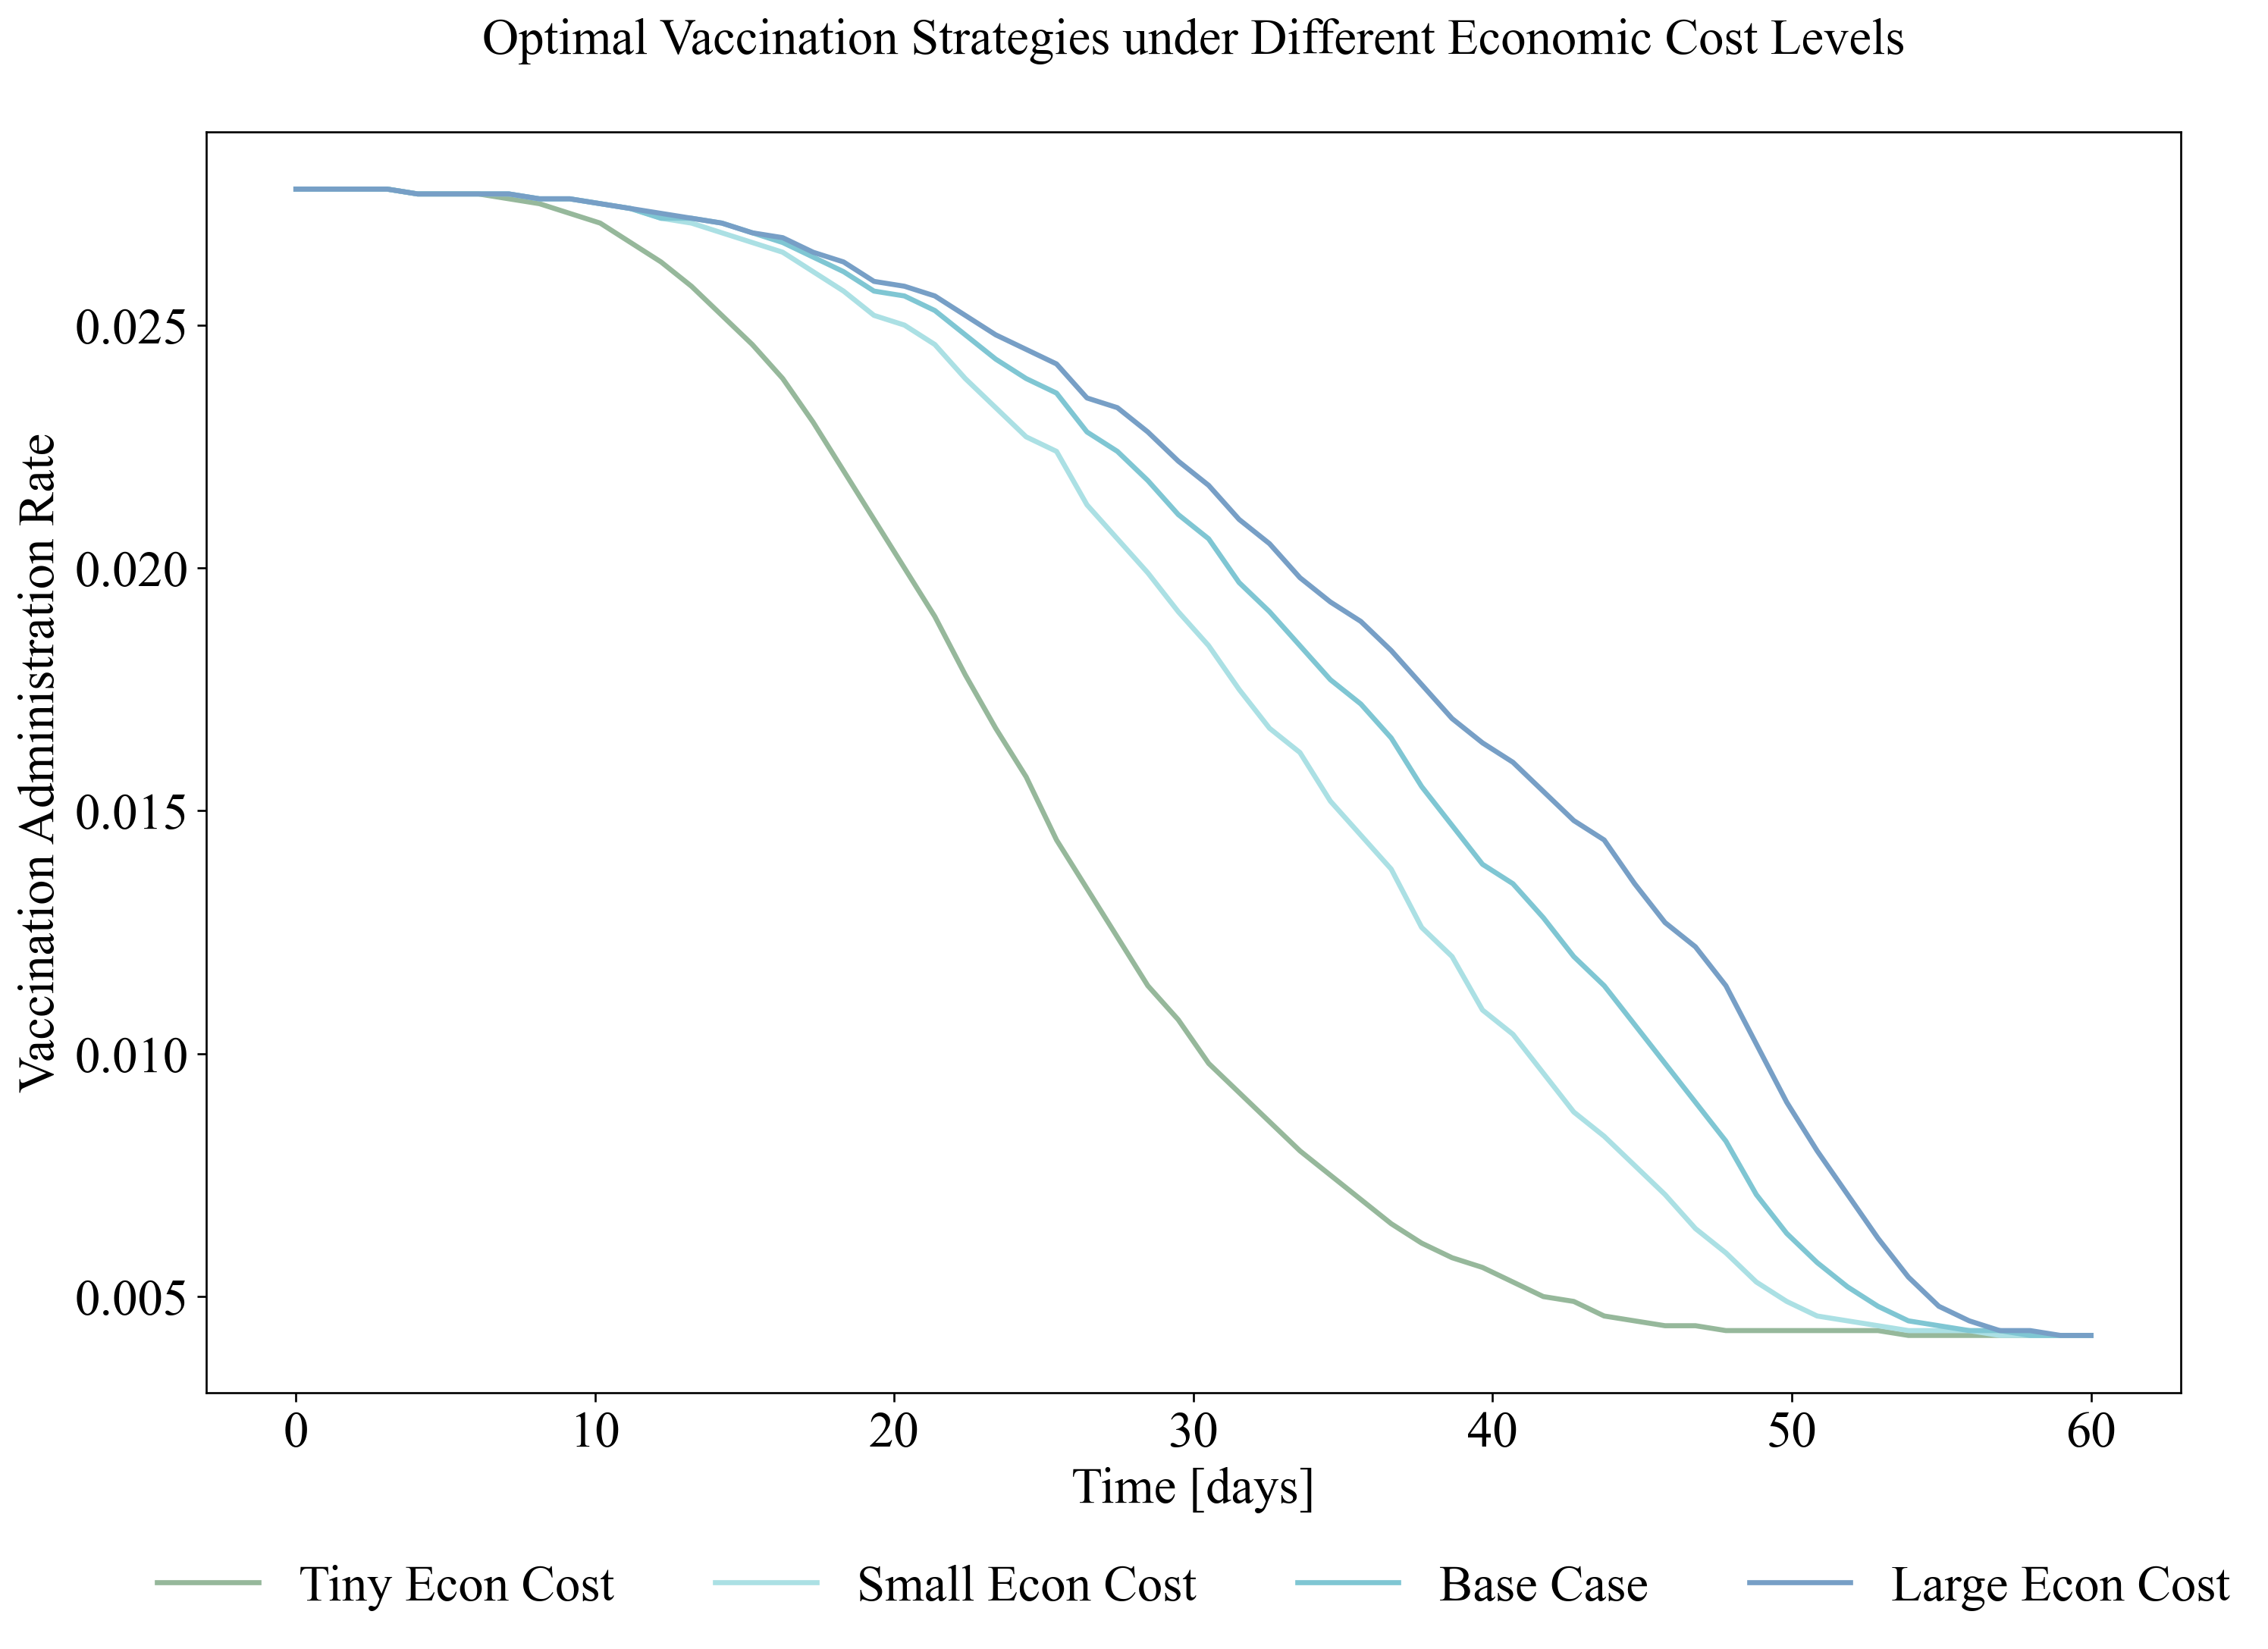

In [55]:
t_axis = np.linspace(0, len(u_opt), len(u_opt))
fig, ax0 = plt.subplots(1, 1, figsize =(14, 9), dpi = 240, sharey = True)

ax0.plot(t_axis, u_tiny_econ_cost, lw = 2, color = new_green1, label = 'Tiny Econ Cost')
ax0.plot(t_axis, u_small_econ_cost, lw = 2, color = new_green2, label = 'Small Econ Cost')
ax0.plot(t_axis, u_opt, lw = 2, color = new_green, label = 'Base Case')
ax0.plot(t_axis, u_large_econ_cost, lw = 2, color = new_green4, label = 'Large Econ Cost')
ax0.set_xlabel('Time [days]', fontsize=20, family='Times New Roman')
ax0.set_ylabel('Vaccination Administration Rate', fontsize=20, family='Times New Roman')
ax0.set_title('Optimal Vaccination Strategies under Different Economic Cost Levels', fontsize=20,  y=1.05) 
ax0.tick_params(axis='both', which='major', labelsize=20)

#ax0.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
ax0.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, fontsize=20)
plt.rc('font', family='Times New Roman')
#plt.tight_layout()
plt.show()

### Different Vacc cost

In [56]:
u_tiny_vacc_cost = np.array([
   0.0278,0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0276,0.0276,
   0.0276,0.0275,0.0273,0.0273,0.0272,0.0270,0.0269,0.0266,0.0264,0.0260,
   0.0260,0.0258,0.0254,0.0250,0.0248,0.0245,0.0239,0.0237,0.0233,0.0227,
   0.0222,0.0216,0.0212,0.0204,0.0200,0.0197,0.0191,0.0186,0.0180,0.0175,
   0.0171,0.0168,0.0164,0.0159,0.0151,0.0144,0.0140,0.0133,0.0122,0.0111,
   0.0099,0.0088,0.0073,0.0059,0.0049,0.0044,0.0042,0.0042,0.0053,0.0053])

u_small_vacc_cost = np.array([
    0.0278,0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0276,0.0276,
    0.0275,0.0274,0.0273,0.0272,0.0271,0.0269,0.0268,0.0265,0.0263,0.0259,
    0.0258,0.0256,0.0251,0.0247,0.0244,0.0241,0.0234,0.0231,0.0226,0.0220,
    0.0215,0.0208,0.0202,0.0195,0.0189,0.0185,0.0179,0.0171,0.0164,0.0158,
    0.0153,0.0147,0.0141,0.0135,0.0126,0.0118,0.0111,0.0103,0.0091,0.0079,
    0.0069,0.0062,0.0054,0.0048,0.0045,0.0043,0.0042,0.0042,0.0045,0.0045])

u_large_vacc_cost = np.array([
    0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0277,0.0276,0.0276,
    0.0275,0.0274,0.0272,0.0271,0.0269,0.0267,0.0265,0.0261,0.0258,0.0253,
    0.0251,0.0246,0.0240,0.0235,0.0229,0.0225,0.0215,0.0209,0.0201,0.0194,
    0.0188,0.0178,0.0171,0.0164,0.0156,0.0150,0.0143,0.0131,0.0125,0.0115,
    0.0111,0.0103,0.0095,0.0089,0.0083,0.0077,0.0070,0.0064,0.0057,0.0052,
    0.0049,0.0047,0.0045,0.0044,0.0043,0.0043,0.0043,0.0043,0.0043,0.0043])

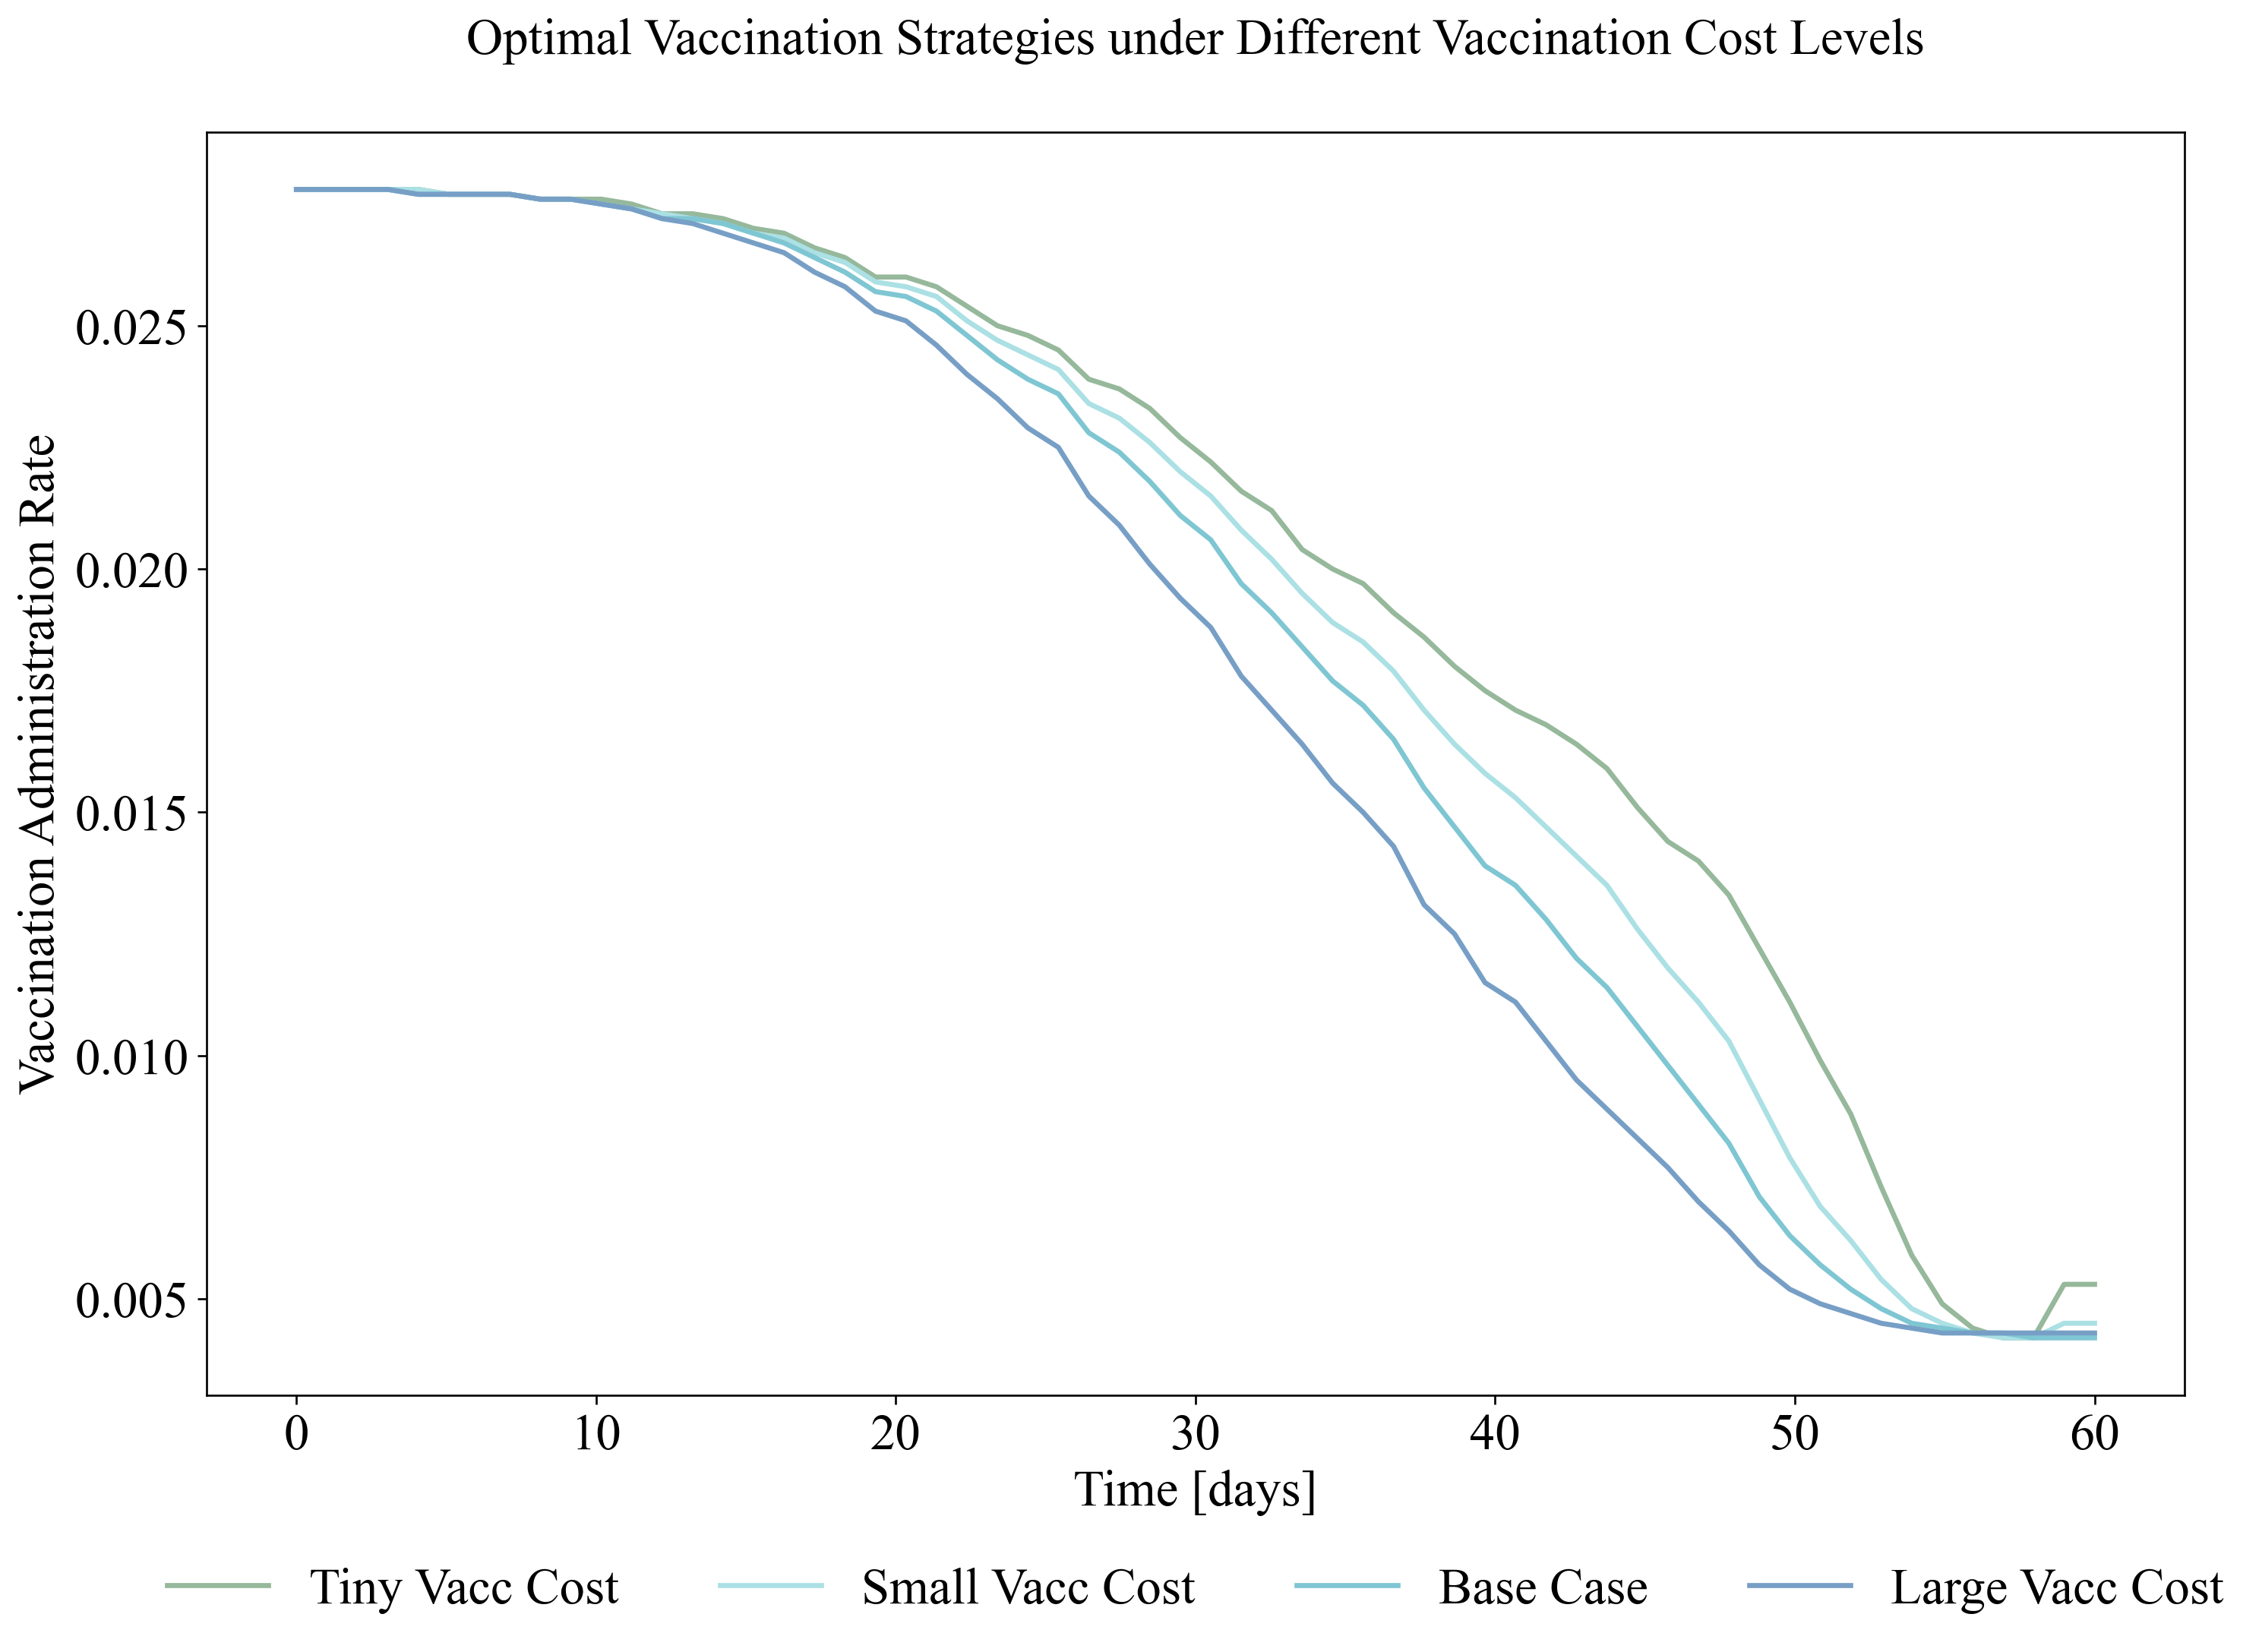

In [57]:
t_axis = np.linspace(0, len(u_opt), len(u_opt))
fig, ax0 = plt.subplots(1, 1, figsize =(14, 9), dpi = 240, sharey = True)

ax0.plot(t_axis, u_tiny_vacc_cost, lw = 2, color = new_green1, label = 'Tiny Vacc Cost')
ax0.plot(t_axis, u_small_vacc_cost, lw = 2, color = new_green2, label = 'Small Vacc Cost')
ax0.plot(t_axis, u_opt, lw = 2, color = new_green, label = 'Base Case')
ax0.plot(t_axis, u_large_vacc_cost, lw = 2, color = new_green4, label = 'Large Vacc Cost')
ax0.set_xlabel('Time [days]', fontsize=20, family='Times New Roman')
ax0.set_ylabel('Vaccination Administration Rate', fontsize=20, family='Times New Roman')
ax0.set_title('Optimal Vaccination Strategies under Different Vaccination Cost Levels', fontsize=20,  y=1.05) 
ax0.tick_params(axis='both', which='major', labelsize=20)

#ax0.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
ax0.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, fontsize=20)
plt.rc('font', family='Times New Roman')
#plt.tight_layout()
plt.show()

### Different Range (vacc hes)

In [58]:
u_small_range = np.array([
    0.0199,0.0199,0.0199,0.0199,0.0199,0.0198,0.0198,0.0198,0.0198,0.0198,0.0198,
    0.0197,0.0197,0.0197,0.0196,0.0196,0.0195,0.0194,0.0193,0.0191,0.0191,0.0190,
    0.0189,0.0186,0.0185,0.0184,0.0182,0.0180,0.0179,0.0176,0.0172,0.0170,0.0168, 
    0.0163,0.0160,0.0156,0.0153,0.0148,0.0143,0.0140,0.0136,0.0130,0.0125,0.0121,
    0.0115,0.0109,0.0104,0.0099,0.0091,0.0080,0.0073,0.0065,0.0056,0.0048,0.0044, 
    0.0042,0.0042,0.0041,0.0041,0.0044])

u_mild_range = np.array([
    0.0238, 0.0238, 0.0238, 0.0238, 0.0238, 0.0238, 0.0238, 0.0238, 0.0237, 0.0237, 
    0.0237, 0.0236, 0.0235, 0.0235, 0.0234, 0.0233, 0.0232, 0.023, 0.0228, 0.0226,
    0.0225, 0.0224, 0.0221, 0.0217, 0.0215, 0.0213,0.0208, 0.0207, 0.0203, 0.0197, 
    0.0194, 0.0189, 0.0184, 0.0177, 0.0172,0.0167, 0.0162, 0.0155, 0.0148, 0.0143, 
    0.0138, 0.0132, 0.0125, 0.012, 0.0113, 0.0105, 0.01, 0.0092, 0.0082, 0.0071,
    0.0064, 0.0057, 0.005, 0.0046, 0.0044, 0.0043, 0.0042, 0.0042, 0.0042, 0.0042])

u_large_range = np.array([ 0.0317,
    0.0318, 0.0317, 0.0317, 0.0317, 0.0317, 0.0316, 0.0316, 0.0315, 0.0314, 0.0313, 
    0.0312, 0.0309, 0.0307, 0.0306, 0.0302, 0.0300, 0.0295, 0.029, 0.0284, 0.0281, 
    0.0275, 0.0268, 0.0262, 0.0255, 0.025, 0.0238, 0.0233, 0.0224, 0.0216, 0.0208, 
    0.0197, 0.0192, 0.0185, 0.0176, 0.017, 0.0162, 0.0149, 0.0142, 0.0132, 0.0127, 
    0.0119, 0.011, 0.0104, 0.0096, 0.0089, 0.0081, 0.0073, 0.0065, 0.0058, 0.0053, 
    0.005, 0.0047, 0.0045, 0.0044, 0.0043, 0.0043, 0.0043, 0.0043, 0.0043])

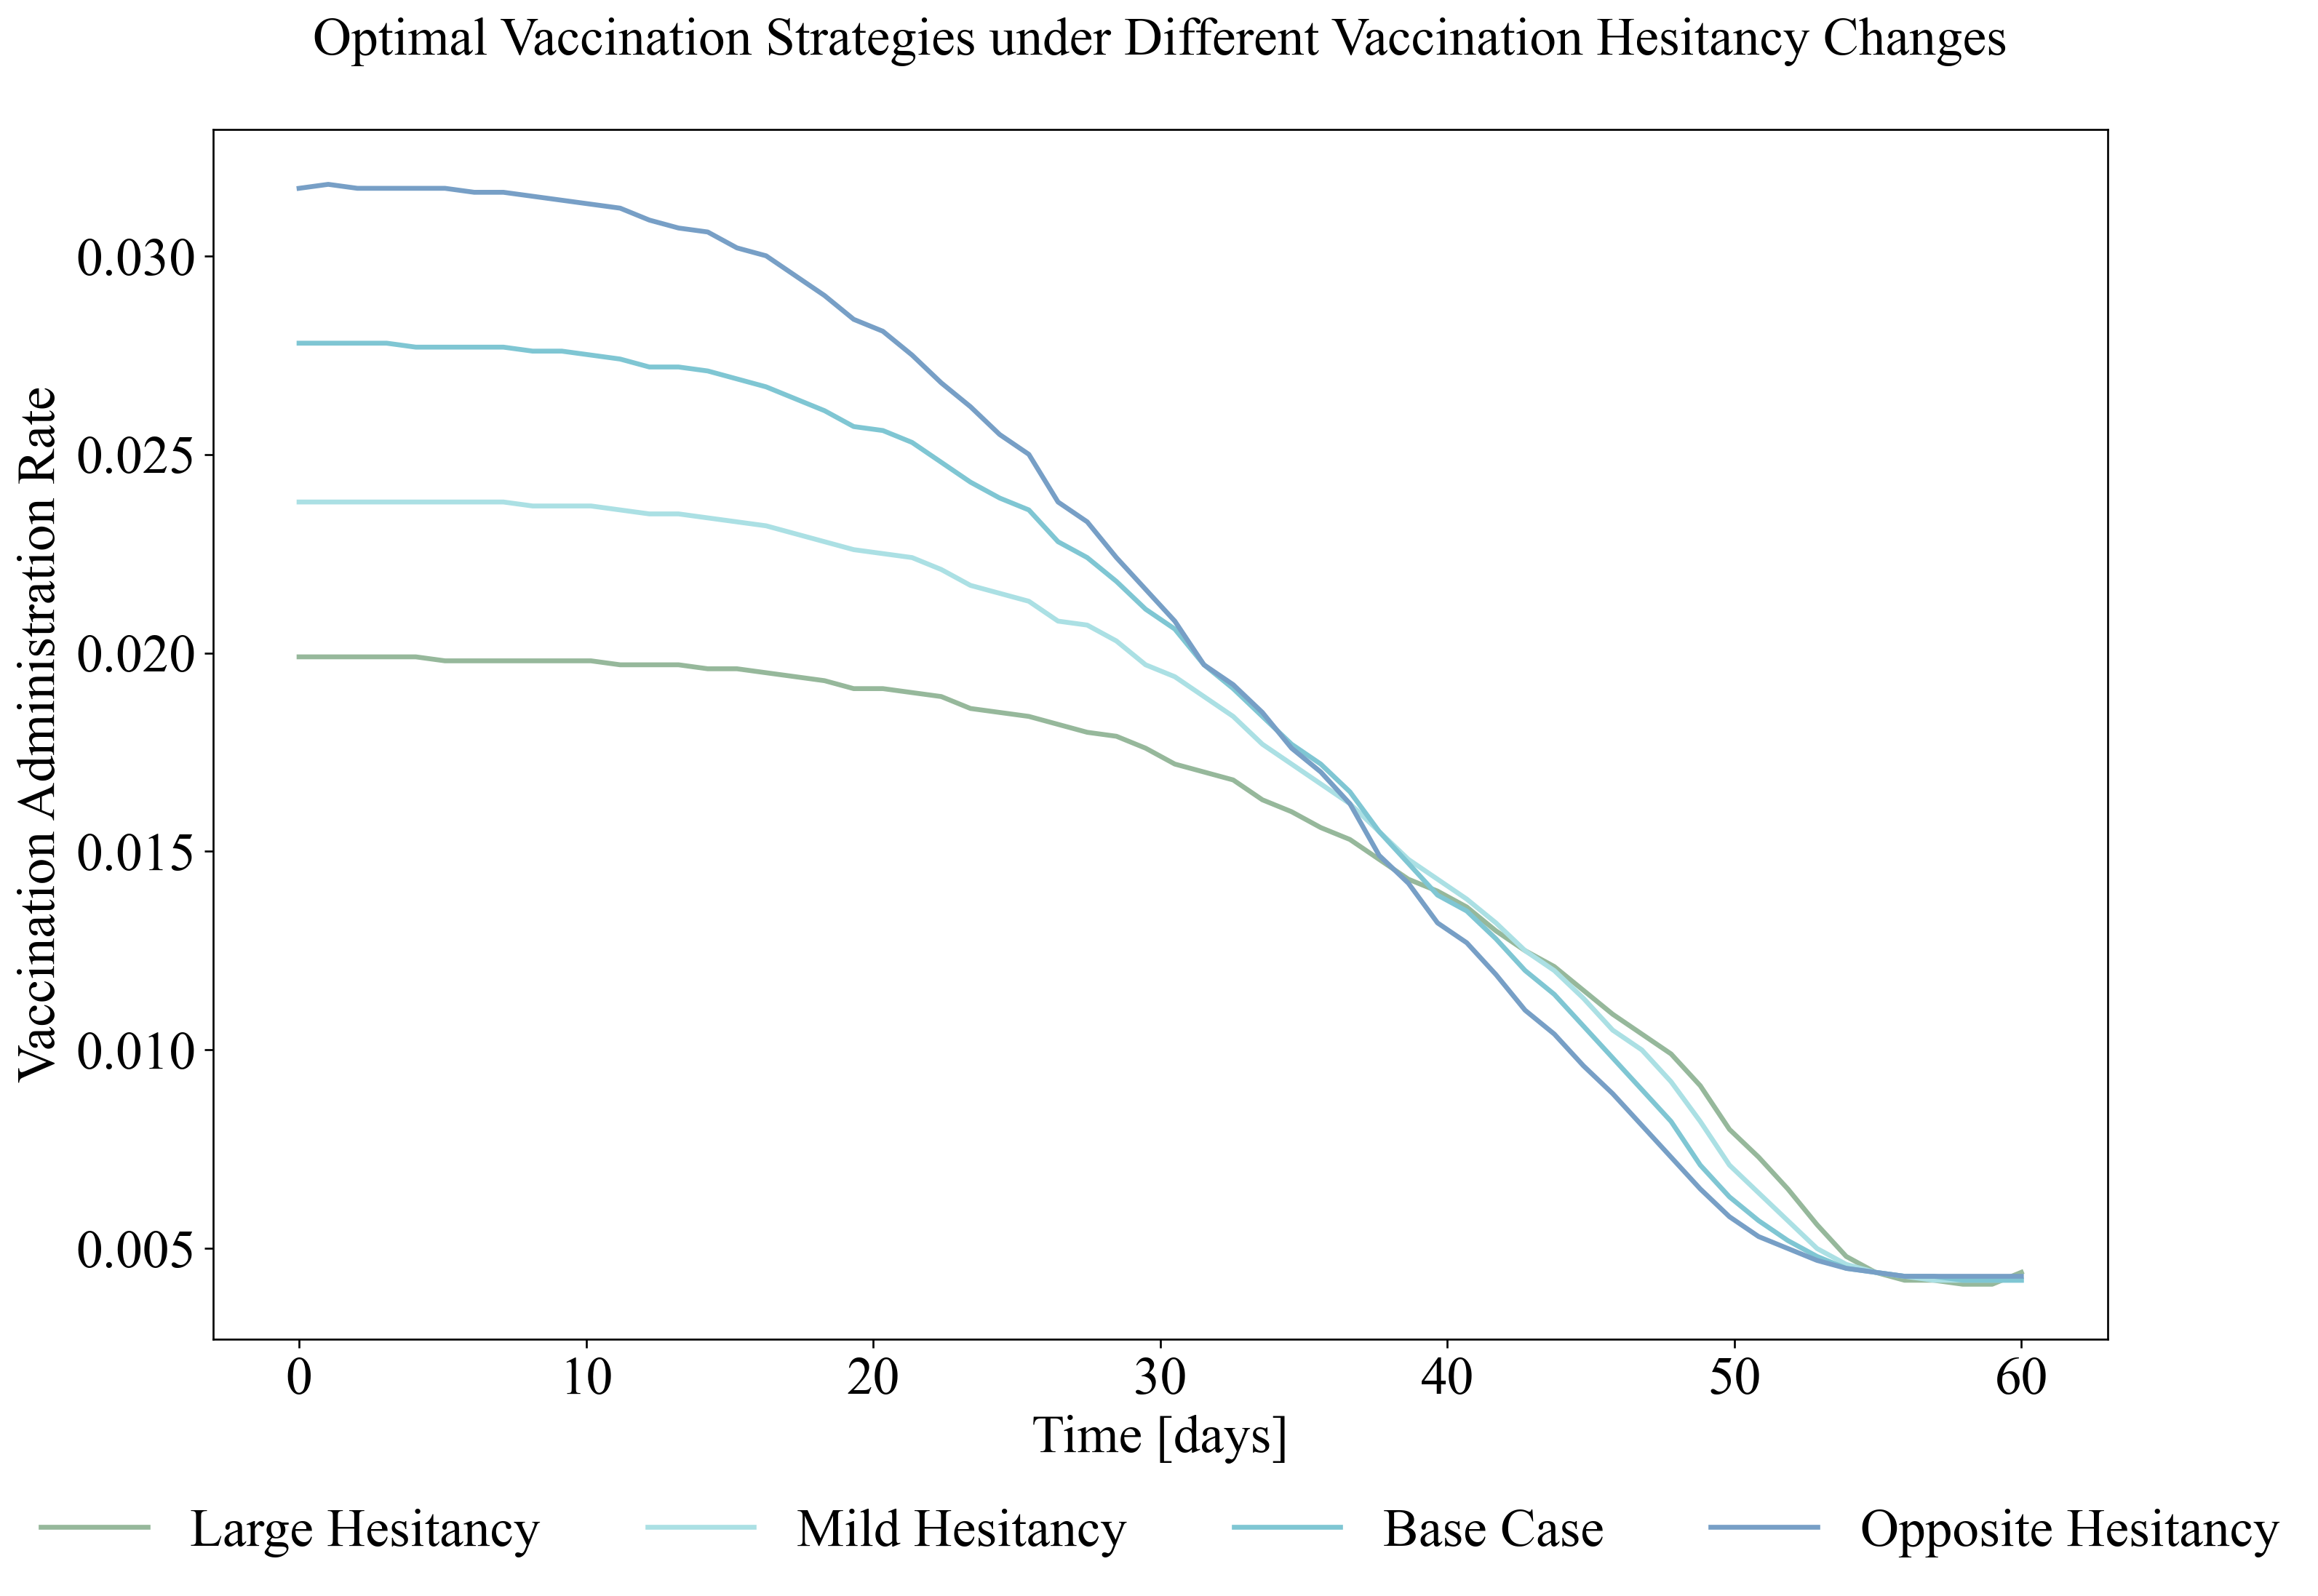

In [59]:
t_axis = np.linspace(0, len(u_opt), len(u_opt))
fig, ax0 = plt.subplots(1, 1, figsize =(14, 9), dpi = 240, sharey = True)

ax0.plot(t_axis, u_small_range, lw = 2, color = new_green1, label = 'Large Hesitancy')
ax0.plot(t_axis, u_mild_range, lw = 2, color = new_green2, label = 'Mild Hesitancy')
ax0.plot(t_axis, u_opt, lw = 2, color = new_green, label = 'Base Case')
ax0.plot(t_axis, u_large_range, lw = 2, color = new_green4, label = 'Opposite Hesitancy')
ax0.set_xlabel('Time [days]', fontsize=22, family='Times New Roman')
ax0.set_ylabel('Vaccination Administration Rate', fontsize=22, family='Times New Roman')
ax0.set_title('Optimal Vaccination Strategies under Different Vaccination Hesitancy Changes', fontsize=22,  y=1.05, family='Times New Roman') 
ax0.tick_params(axis='both', which='major', labelsize=22)

#ax0.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
ax0.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, fontsize=22)
plt.rc('font', family='Times New Roman')
#plt.tight_layout()
plt.show()

### 6 plots

In [60]:
u_init025 = np.array([ 
    0.0278,0.0278,0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0277,0.0276,
    0.0276,0.0274,0.0274,0.0272,0.0272,0.0271,0.0269,0.0266,0.0266,0.0263,0.0265,
    0.0263,0.026,0.0261,0.0258,0.0253,0.0255,0.0252,0.0252,0.0246,0.0243,0.024,
    0.0236,0.0235,0.023,0.0227,0.022,0.0214,0.0207,0.0199,0.019,0.0182,0.0172,
    0.0166,0.0151,0.0141,0.0129,0.0116,0.0101,0.0089,0.0075,0.0064,0.0054,0.0047,
    0.0043,0.0042,0.0042,0.0042,0.0042
])


u_init075 = np.array([ 
    0.0277,0.0277,0.0276,0.0276,0.0275,0.0274,0.0273,0.0271,0.0269,0.0264,0.026,
    0.0255,0.0251,0.0245,0.0241,0.0236,0.0229,0.0224,0.0219,0.0213,0.0205,0.0202,
    0.0198,0.0188,0.0184,0.018,0.0172,0.0166,0.016,0.0156,0.0151,0.0146,0.0139,
    0.0137,0.0129,0.0124,0.012,0.0113,0.0109,0.0104,0.0097,0.0093,0.0087,0.0081,
    0.0076,0.0071,0.0066,0.0061,0.0056,0.0052,0.0049,0.0046,0.0045,0.0043,0.0043,
    0.0042,0.0042,0.0042,0.0042,0.0042])

u_init085 = np.array([ 
    0.0229,0.0214,0.0206,0.0195,0.0183,0.0177,0.0172,0.0165,0.0161,0.0153,0.0147,
    0.0147,0.0143,0.0137,0.0132,0.0126,0.0123,0.0123,0.0122,0.0118,0.0118,0.0112,
    0.0108,0.0107,0.0103,0.0098,0.0096,0.0097,0.0096,0.0093,0.0091,0.0087,0.0085,
    0.0083,0.0081,0.0078,0.0075,0.0074,0.0072,0.0069,0.0066,0.0063,0.0061,0.0057,
    0.0055,0.0054,0.0051,0.0048,0.0046,0.0045,0.0044,0.0044,0.0043,0.0043,0.0042,
    0.0042,0.0042,0.0042,0.0042,0.0042])

u_init09 = np.array([ 
    0.0074,0.0083,0.0085,0.0089,0.0092,0.0092,0.0092,0.009,0.0091,0.0089,0.0088,
    0.0087,0.0086,0.0086,0.0083,0.0082,0.0083,0.0083,0.0081,0.008,0.0081,0.008,
    0.0079,0.0079,0.0076,0.0073,0.0074,0.0073,0.0072,0.0072,0.007,0.0069,0.0066,
    0.0066,0.0063,0.0064,0.0061,0.0061,0.0059,0.0057,0.0056,0.0054,0.0053,0.0051,
    0.0049,0.0049,0.0047,0.0045,0.0044,0.0044,0.0043,0.0043,0.0043,0.0042,0.0042,
    0.0042,0.0042,0.0042,0.0042,0.0042])

u_init095 = np.array([ 
    0.0046,0.0046,0.0047,0.0047,0.0047,0.0047,0.0047,0.0047,0.0047,0.0047,0.0047,
    0.0047,0.0047,0.0047,0.0047,0.0047,0.0047,0.0047,0.0048,0.0047,0.0047,0.0048,
    0.0048,0.0048,0.0047,0.0047,0.0048,0.0047,0.0047,0.0047,0.0047,0.0047,0.0047,
    0.0047,0.0046,0.0046,0.0046,0.0046,0.0045,0.0045,0.0045,0.0045,0.0044,0.0044,
    0.0044,0.0044,0.0043,0.0043,0.0043,0.0043,0.0043,0.0042,0.0042,0.0042,0.0042,
    0.0042,0.0042,0.0042,0.0042,0.0042])

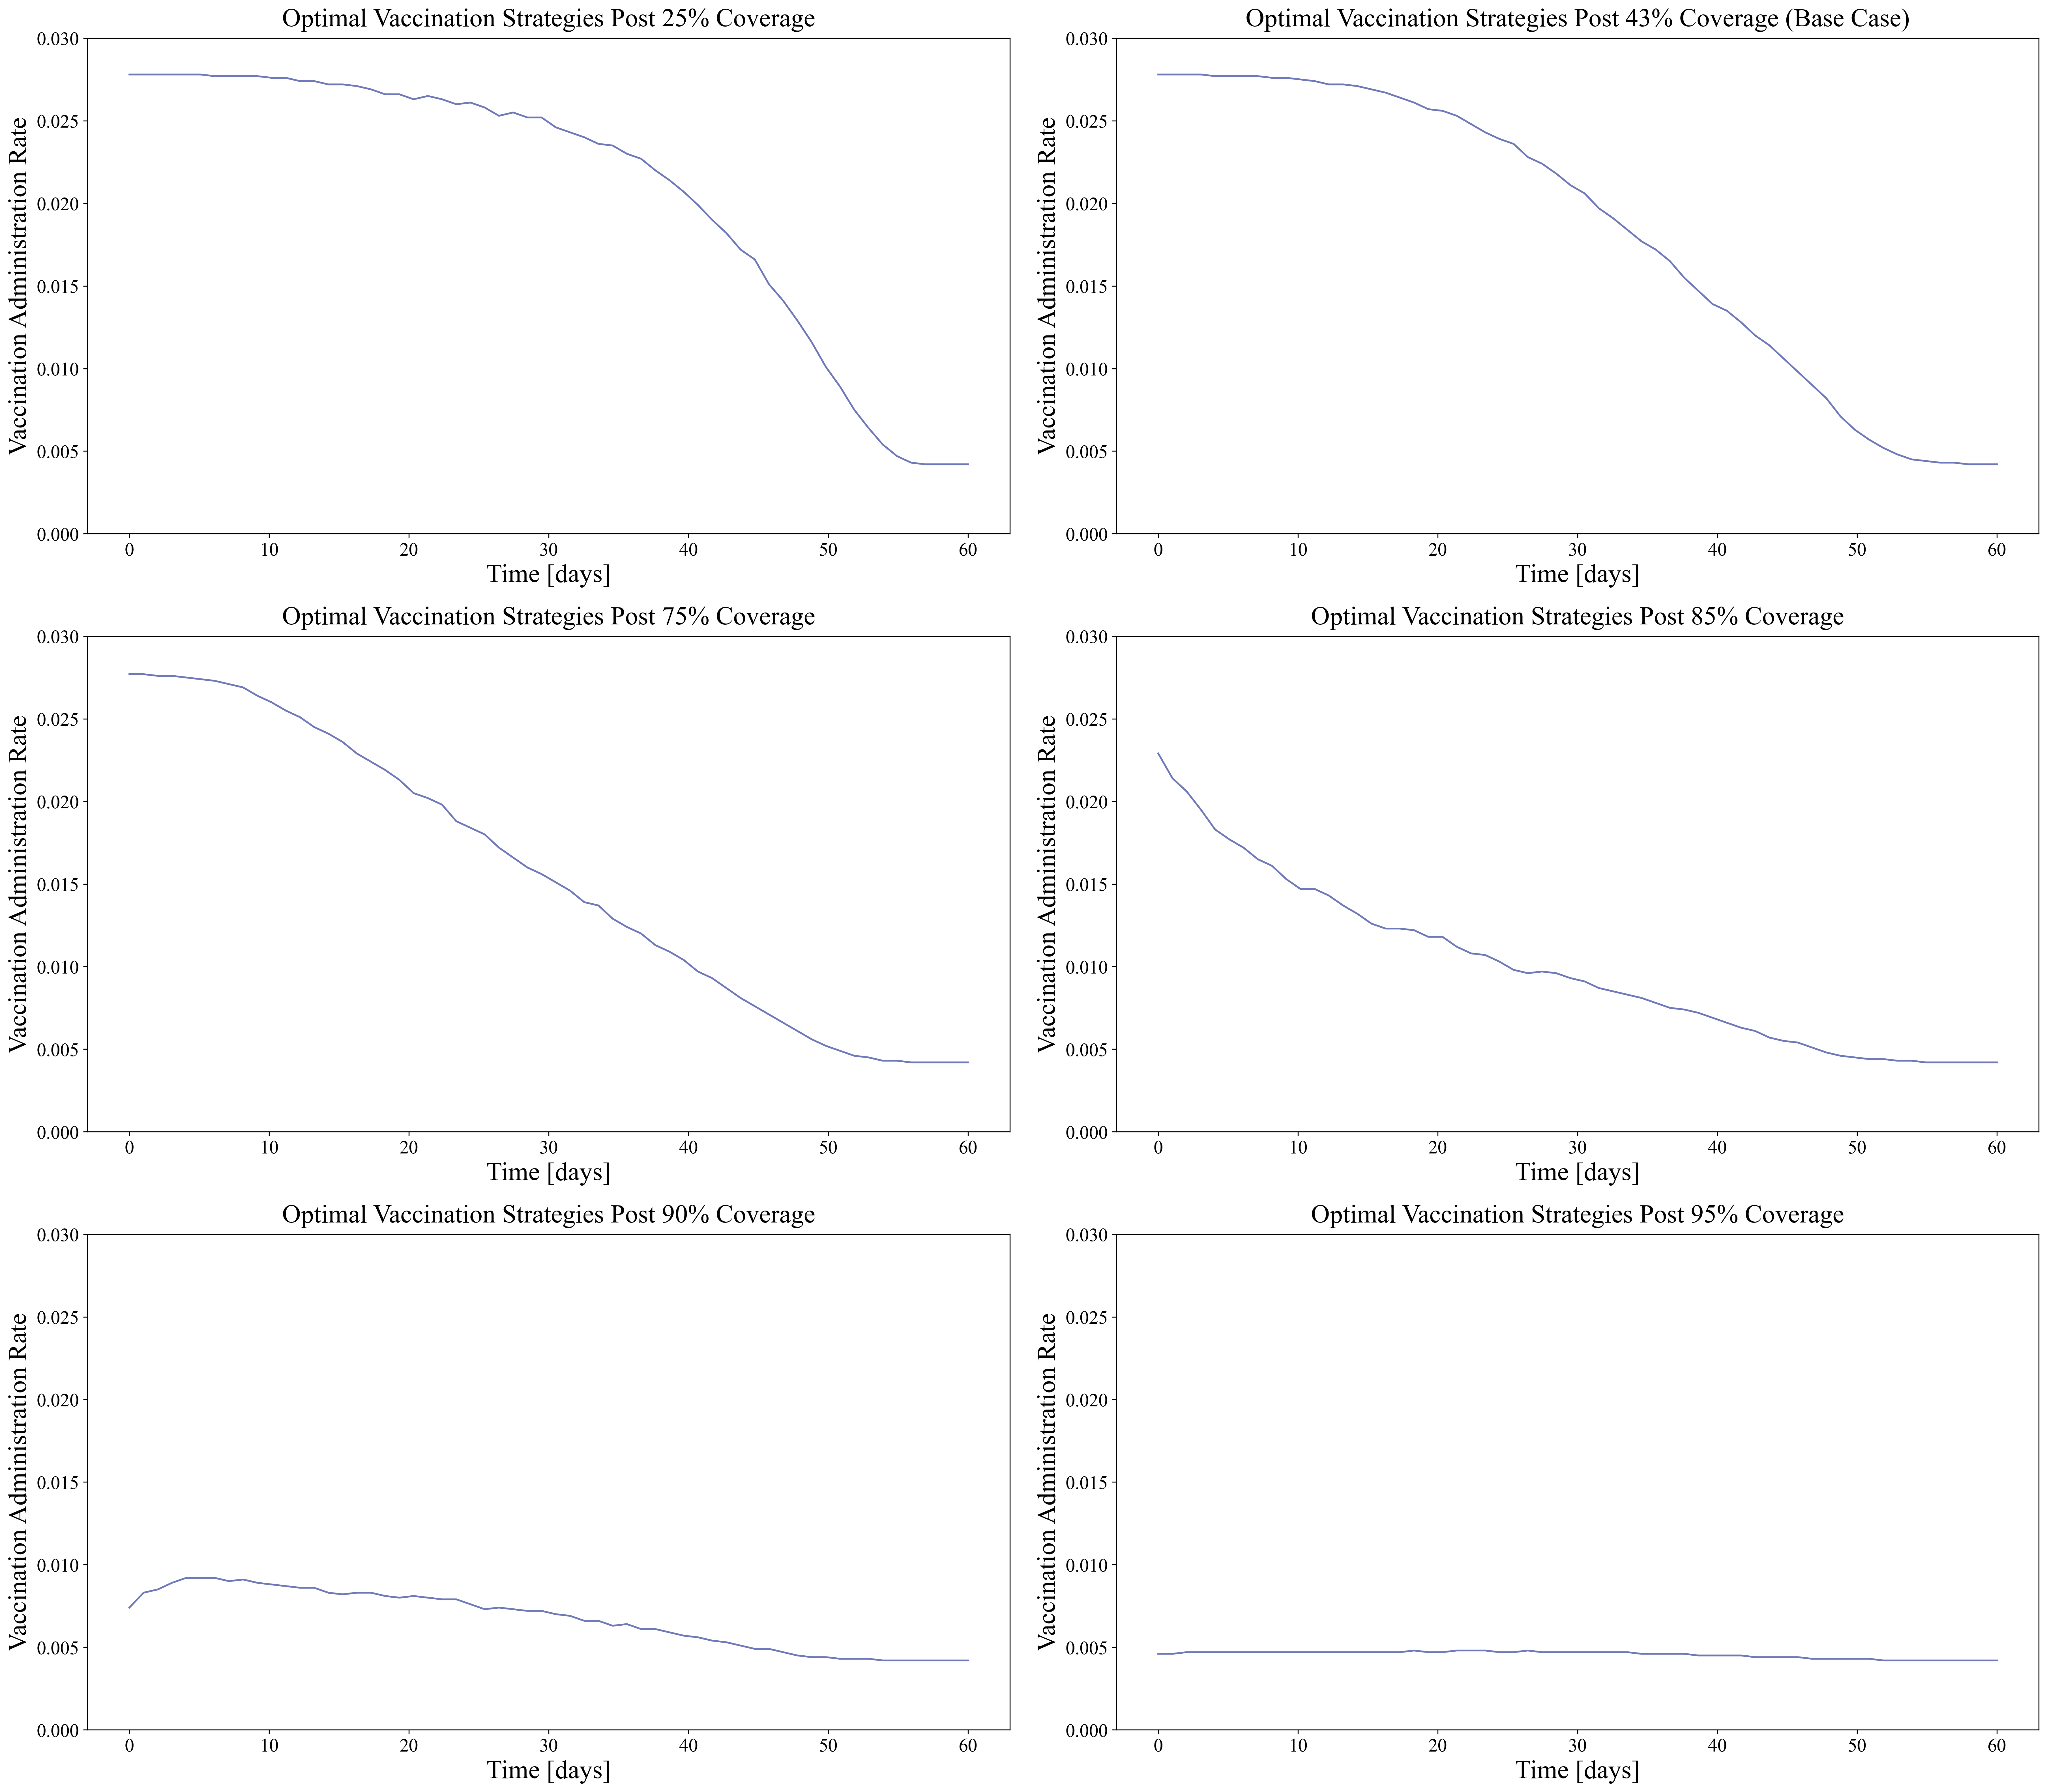

In [61]:
fig, axs = plt.subplots(3, 2, constrained_layout=True, figsize=(24, 21), dpi=300)

# Custom plots for each subplot
def plot_1(ax):
    ax.plot(t_axis, u_init025, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 25% Coverage', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 


def plot_2(ax):
    ax.plot(t_axis, u_opt, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 43% Coverage (Base Case)', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 


def plot_3(ax):
    ax.plot(t_axis, u_init075, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 75% Coverage', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 

def plot_4(ax):
    ax.plot(t_axis, u_init085, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 85% Coverage', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 

def plot_5(ax):
    ax.plot(t_axis, u_init09, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 90% Coverage', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 

def plot_6(ax):
    ax.plot(t_axis, u_init095, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 95% Coverage', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 


# Apply different plots to each subplot
plot_1(axs[0, 0])
plot_2(axs[0, 1])
plot_3(axs[1, 0])
plot_4(axs[1, 1])
plot_5(axs[2, 0])
plot_6(axs[2, 1])


# Display the plot
#plt.show()
plt.savefig('plot_cum_cost_'+str(TEXT)+'.png', dpi=300)

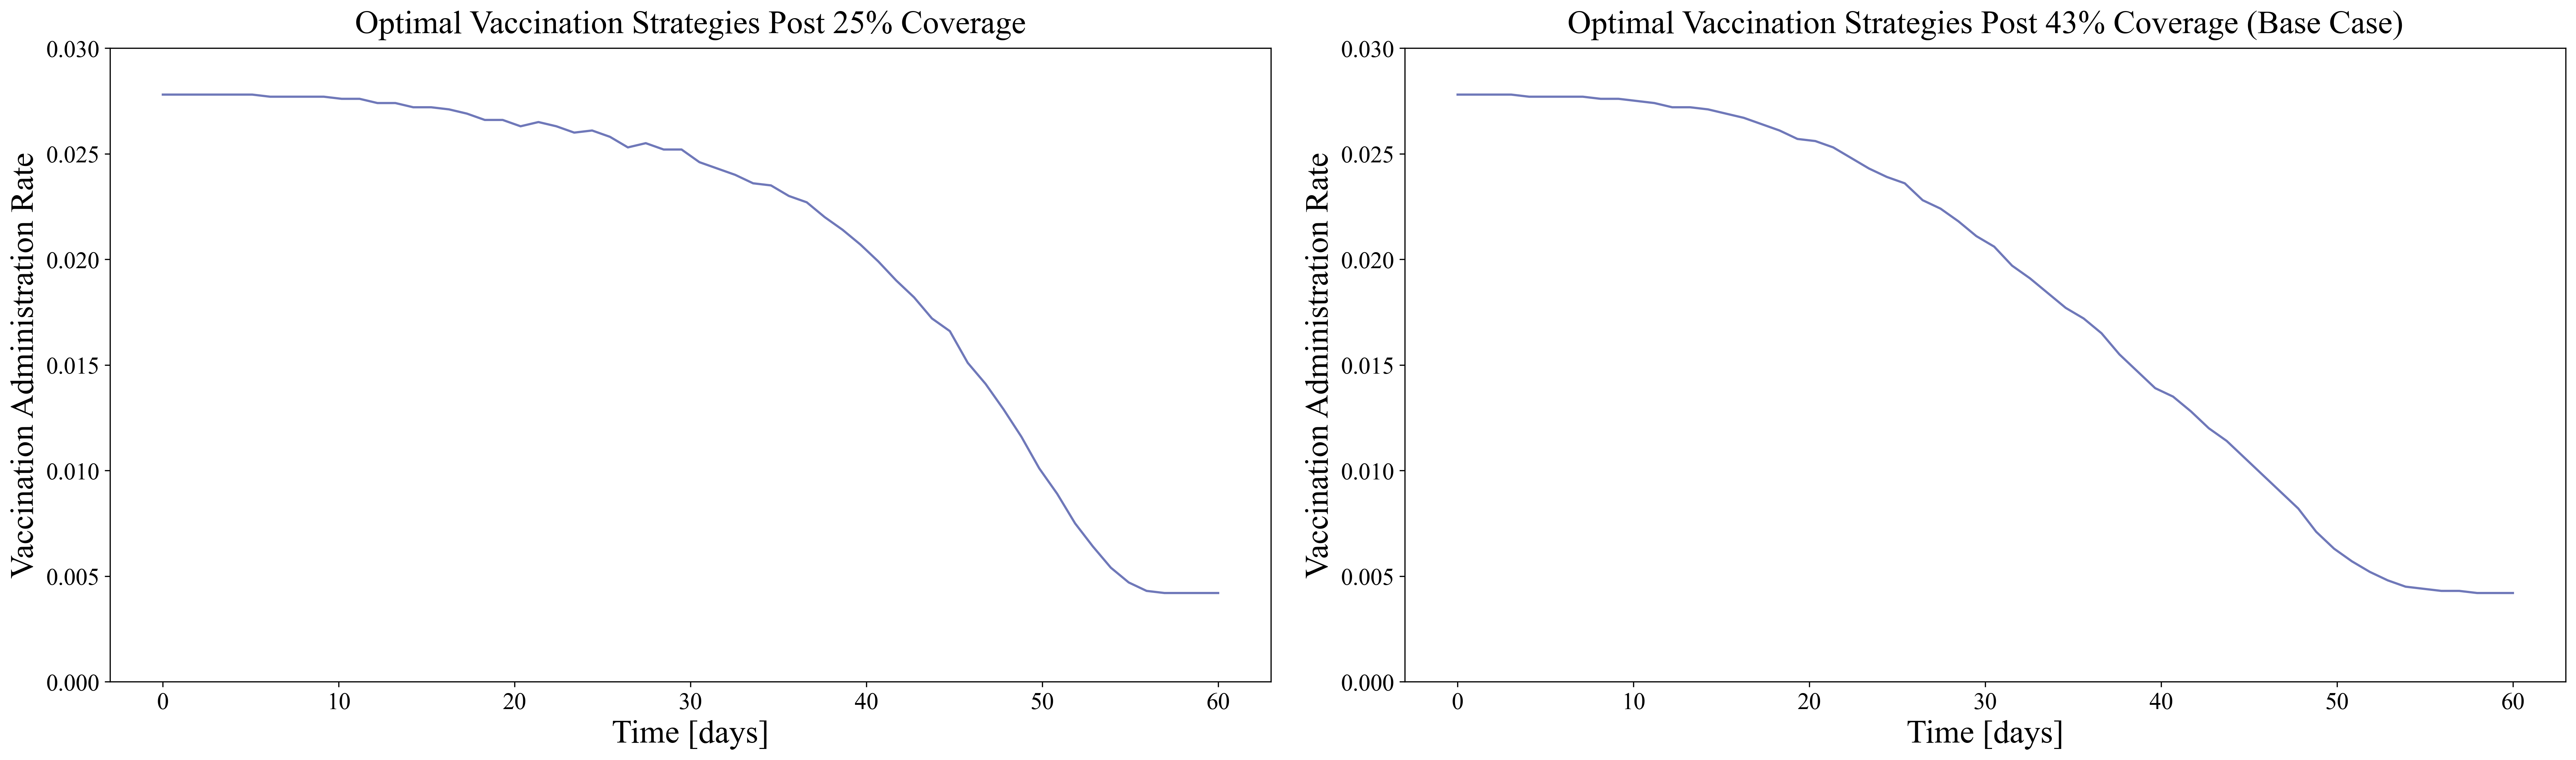

In [64]:
fig, axs = plt.subplots(1, 2, constrained_layout=True, figsize=(24, 7), dpi=300)

# Custom plots for each subplot
def plot_1(ax):
    ax.plot(t_axis, u_init025, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 25% Coverage', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 


def plot_2(ax):
    ax.plot(t_axis, u_opt, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 43% Coverage (Base Case)', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 


# Apply different plots to each subplot
plot_1(axs[0])
plot_2(axs[1])

# Display the plot
plt.show()
#plt.savefig('plot_cum_cost_'+str(TEXT)+'.png', dpi=300)

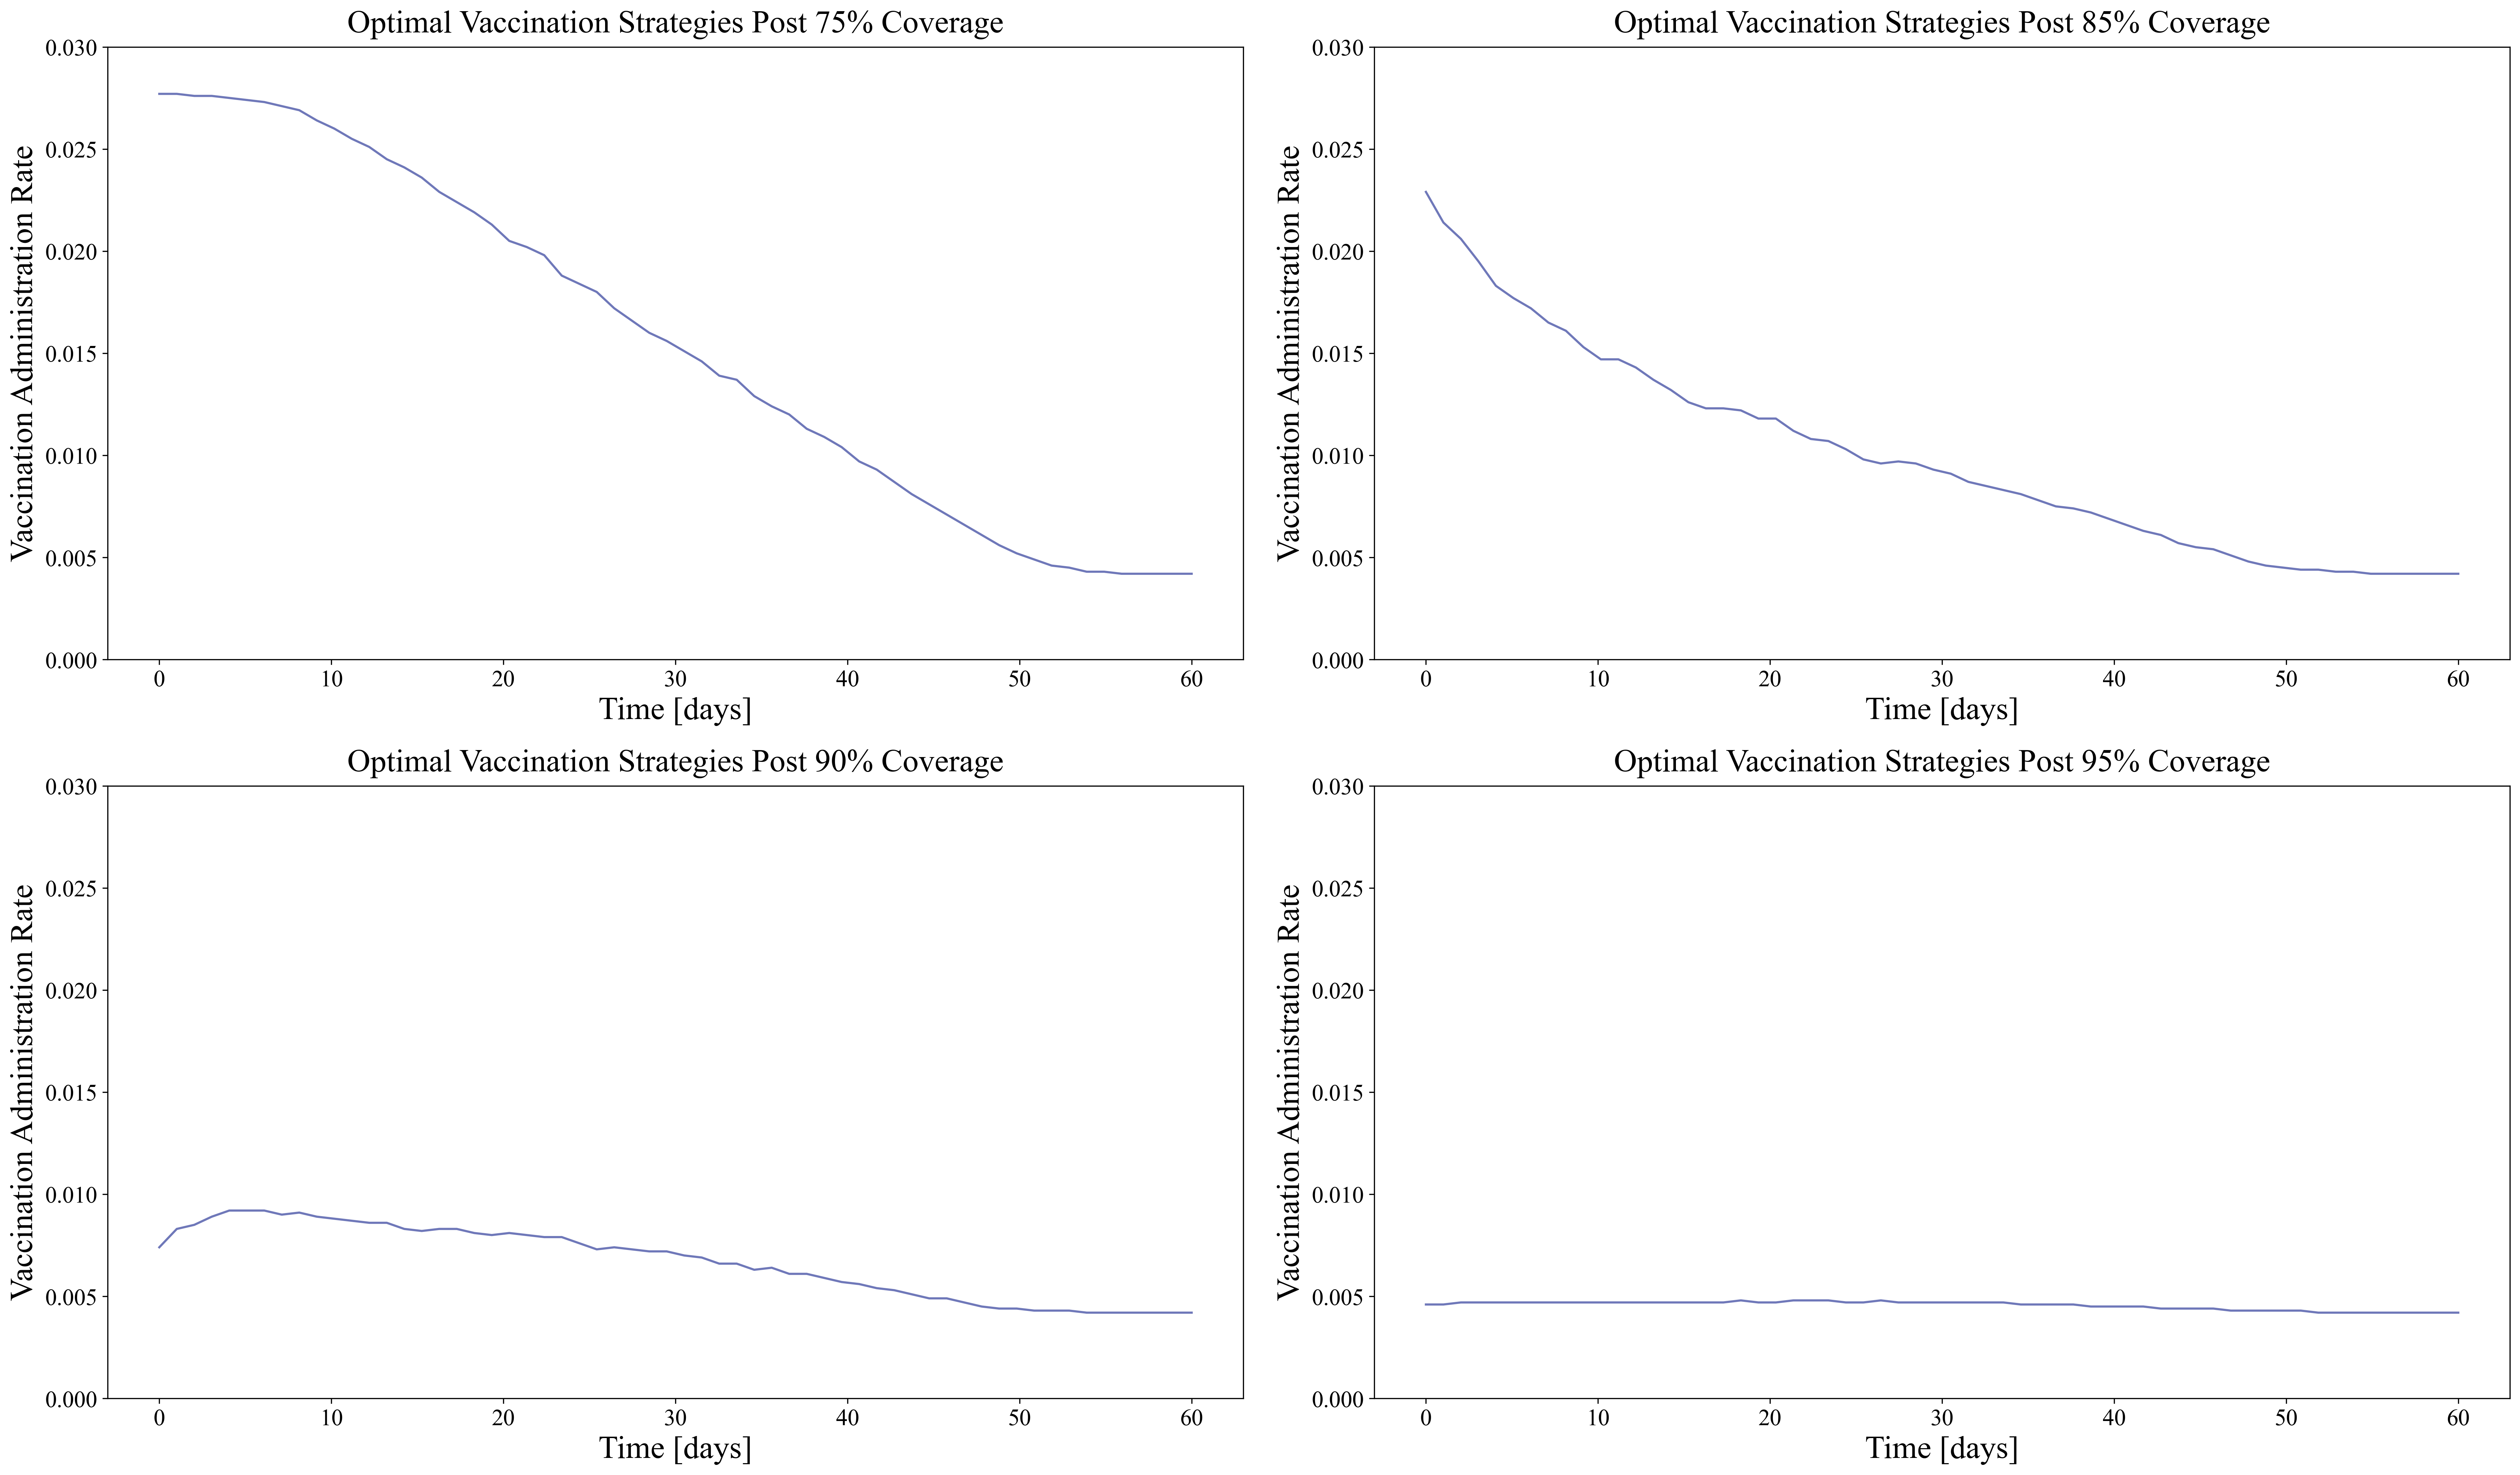

In [65]:
fig, axs = plt.subplots(2, 2, constrained_layout=True, figsize=(24, 14), dpi=300)

# Custom plots for each subplot

def plot_3(ax):
    ax.plot(t_axis, u_init075, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 75% Coverage', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 

def plot_4(ax):
    ax.plot(t_axis, u_init085, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 85% Coverage', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 

def plot_5(ax):
    ax.plot(t_axis, u_init09, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 90% Coverage', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 

def plot_6(ax):
    ax.plot(t_axis, u_init095, lw = 1.5, color = new_purple, label = 'Optimal vaccination rate')
    ax.set_xlabel('Time [days]',fontsize=22, family='Times New Roman')
    ax.set_ylabel('Vaccination Administration Rate',fontsize=22, family='Times New Roman')
    ax.set_title('Optimal Vaccination Strategies Post 95% Coverage', fontsize=22,  y=1.01, family='Times New Roman')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #ax.legend(loc='upper right', frameon=False, fontsize=20)
    #ax.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
    ax.set_ylim(0, 0.03) 


# Apply different plots to each subplot
plot_3(axs[0, 0])
plot_4(axs[0, 1])
plot_5(axs[1, 0])
plot_6(axs[1, 1])



# Display the plot
#plt.show()
plt.savefig('plot_cum_cost_'+str(TEXT)+'.png', dpi=300)

### Numerical result prove

In [19]:
u_opt_run1 = np.array([
    0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0277,0.0276,0.0276,0.0276,
    0.0274,0.0274,0.0274,0.0271,0.027,0.0267,0.0263,0.0264,0.0261,0.0257,
    0.0256,0.0255,0.0249,0.0242,0.0245,0.0237,0.0225,0.0225,0.0219,0.0211,
    0.0206,0.0204,0.0193,0.0183,0.0177,0.0172,0.016,0.0152,0.0145,0.0135,
    0.0129,0.0121,0.0115,0.0107,0.0107,0.0099,0.009,0.0082,0.007,0.0064,
    0.0056,0.0051,0.0048,0.0045,0.0043,0.0043,0.0042,0.0042,0.0042,0.0042])

u_opt_run2 = np.array([
    0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0277,0.0276,0.0276,
    0.0276,0.0275,0.0274,0.0272,0.027,0.0268,0.0267,0.026,0.0259,0.0254,
    0.0254,0.0252,0.0248,0.0244,0.0241,0.0236,0.0226,0.0224,0.0214,0.0211,
    0.0205,0.0197,0.0189,0.0182,0.0176,0.0168,0.0158,0.0145,0.0141,0.0137,
    0.0129,0.012,0.0117,0.0112,0.0105,0.0098,0.009,0.0084,0.0073,0.0063,
    0.0058,0.0053,0.0048,0.0046,0.0044,0.0043,0.0043,0.0043,0.0043,0.0042])

u_opt_run3 = np.array([ 
    0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0277,0.0276,0.0275,
    0.0275,0.0274,0.0274,0.0272,0.0272,0.0268,0.0269,0.0265,0.026,0.0253,
    0.0251,0.0248,0.024,0.024,0.0234,0.024,0.0229,0.0225,0.0215,0.0206,
    0.0204,0.0193,0.0187,0.0177,0.017,0.016,0.016,0.0148,0.0138,0.0131,
    0.0134,0.012,0.0112,0.0104,0.0096,0.0096,0.0083,0.0077,0.0069,0.0062,
    0.0054,0.0051,0.0048,0.0045,0.0044,0.0043,0.0042,0.0042,0.0042,0.0042])

u_opt_run4 = np.array([ 
    0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0276,0.0276,0.0275,
    0.0275,0.0273,0.0267,0.027,0.0269,0.0266,0.0266,0.0262,0.0261,0.0257,
    0.0256,0.0251,0.0248,0.0238,0.0233,0.0232,0.0227,0.0222,0.0219,0.0215,
    0.0205,0.0195,0.0189,0.0188,0.0177,0.018,0.0171,0.0162,0.0149,0.014,
    0.0135,0.0133,0.0121,0.0115,0.0107,0.0096,0.0093,0.0083,0.0069,0.0061,
    0.0056,0.0054,0.0048,0.0045,0.0044,0.0043,0.0042,0.0042,0.0042,0.0042])

u_opt_run5 = np.array([ 
    0.0278,0.0278,0.0278,0.0278,0.0278,0.0278,0.0277,0.0277,0.0277,0.0277,
    0.0276,0.0276,0.0274,0.0274,0.0272,0.0272,0.027,0.0269,0.0267,0.0263,
    0.0261,0.0257,0.0253,0.025,0.0242,0.0236,0.0231,0.0224,0.0221,0.0213,
    0.0211,0.0198,0.0199,0.0188,0.0184,0.0178,0.0176,0.0168,0.0163,0.0153,
    0.0148,0.0146,0.0134,0.013,0.0114,0.0103,0.0095,0.0086,0.0077,0.0064,
    0.0059,0.0052,0.0049,0.0046,0.0044,0.0044,0.0043,0.0043,0.0043,0.0043])

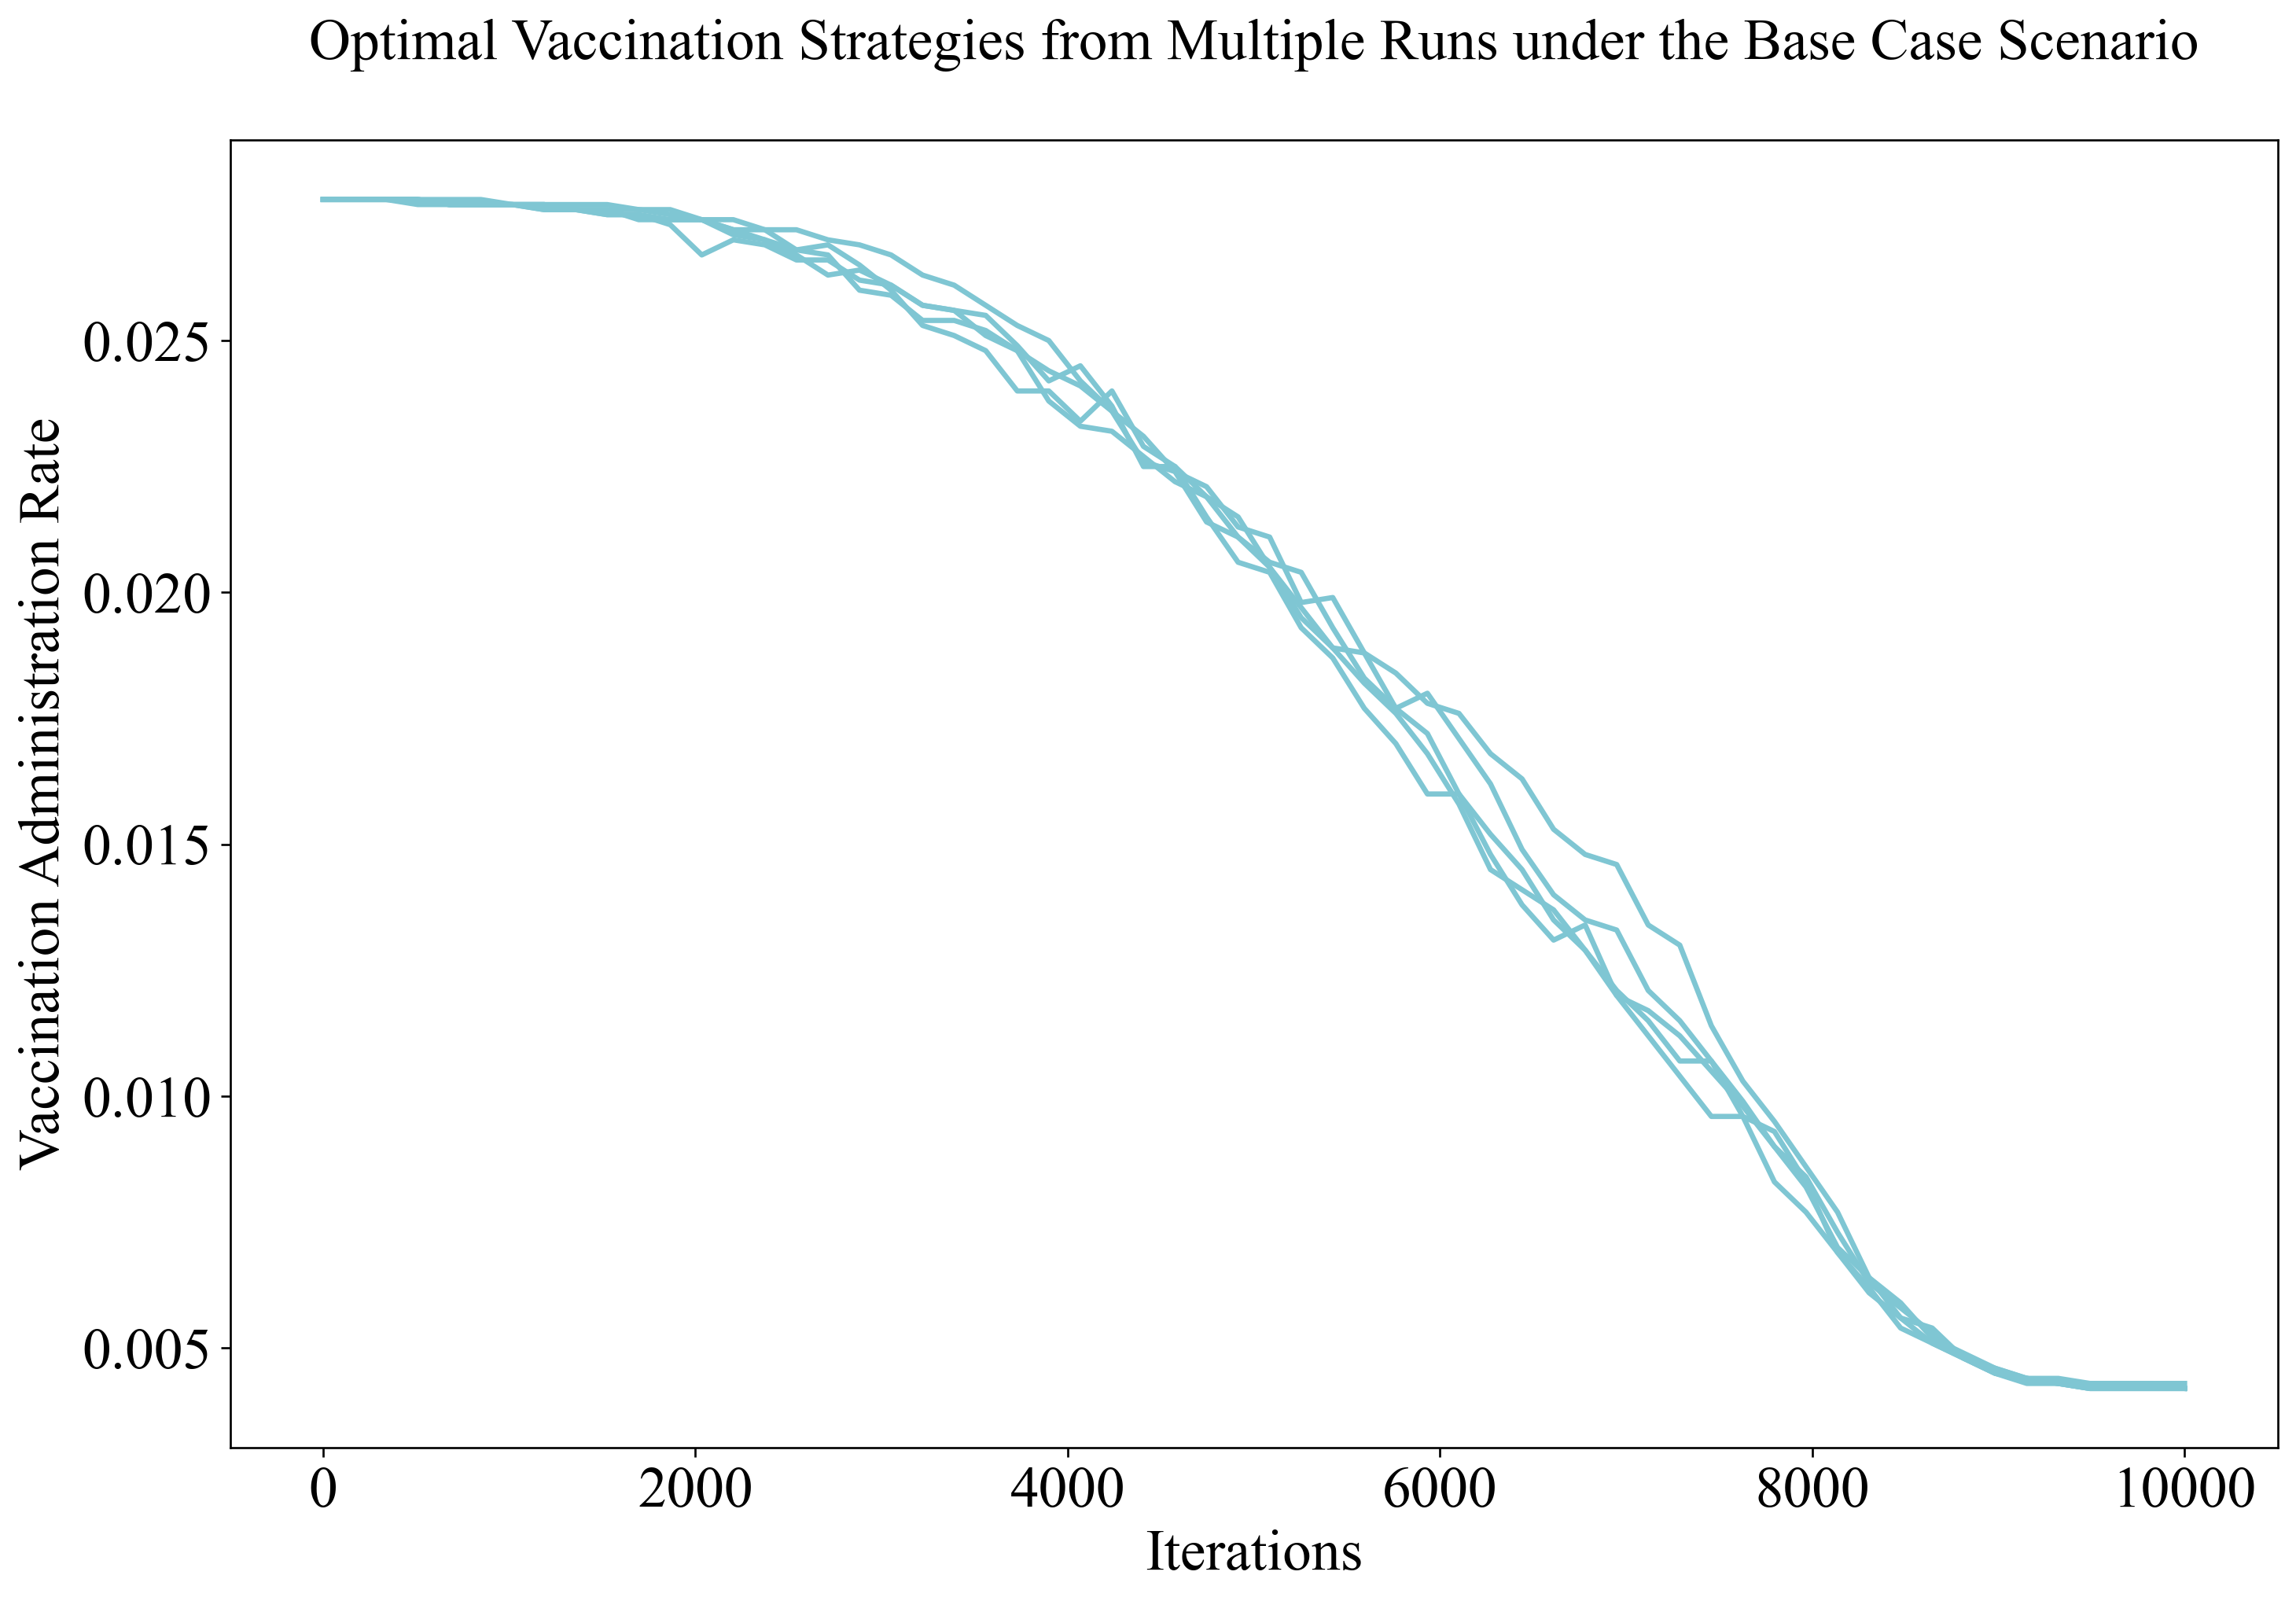

In [20]:
t_axis = np.linspace(0, 10000, len(u_opt_run1))
fig, ax0 = plt.subplots(1, 1, figsize =(14, 9), dpi = 240, sharey = True)

ax0.plot(t_axis, u_opt_run1, lw = 2, color = new_green, label = 'run 1')
ax0.plot(t_axis, u_opt_run2, lw = 2, color = new_green, label = 'run 2')
ax0.plot(t_axis, u_opt_run3, lw = 2, color = new_green, label = 'run 3')
ax0.plot(t_axis, u_opt_run4, lw = 2, color = new_green, label = 'run 4')
ax0.plot(t_axis, u_opt_run5, lw = 2, color = new_green, label = 'run 5')
ax0.set_xlabel('Iterations', fontsize=22, family='Times New Roman')
ax0.set_ylabel('Vaccination Administration Rate', fontsize=22, family='Times New Roman')
ax0.set_title('Optimal Vaccination Strategies from Multiple Runs under the Base Case Scenario', fontsize=22,  y=1.05, family='Times New Roman') 
ax0.tick_params(axis='both', which='major', labelsize=22)

#ax0.grid(True, which='both', axis='y', color='lightgrey', linestyle='--', linewidth=0.7)
#ax0.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, fontsize=22)
plt.rc('font', family='Times New Roman')
#plt.tight_layout()
plt.show()

### Loss function over base case

In [21]:
t_axis = np.linspace(0, 10000, 200)
opt_control_loss =  np.array([ 
    679.984, 677.8074, 675.8356,  675.25,  673.1232,  670.748,  668.3896,  666.3832,  
    664.6802,  663.4398,  662.7558,  660.6024, 660.9036,  659.4296,  659.6082,  659.3452,  
    658.6832,  658.1538,  657.8138, 657.1102,  655.7496,  655.1464,  654.9994,  654.8634,  
    653.6996,  654.1524,  653.6678, 652.6936,  652.1894,  651.5898,  651.7112,  651.578,  
    651.505,  651.2158,  651.2188,  650.6894, 650.2368, 650.0652,  649.7938,  649.6688,  
    650.0832,  649.581,  649.455,  649.3916,  649.269,  649.3858,  649.3458, 649.1496, 
    649.0908,  649.4804,  649.398,  648.635,  648.3434,  648.5222,  648.309,  648.0854, 
    648.2614,  648.1938,  648.2602,  648.2696,  648.2008,  648.186,  647.7176,  647.601, 
    647.8664, 648.1228,  648.1264,  648.2502,  648.1808,  647.8458,  647.3686,  647.5186, 
    647.557, 647.697,  647.6854,  647.4694,  647.5962,  647.3422,  647.1706,  647.2022,  
    647.1072,  647.0946,  647.1652, 647.2668,  647.1976,  647.014,  647.139,  647.367,  
    647.5842,  647.7242,  647.5182,  647.2122,  647.0004, 646.925, 646.9674, 647.0922, 
    647.156,  647.312,  647.3114,  647.121,  647.211,  647.1784,  647.1866,  647.1692,  
    647.1544,  647.153, 647.1434,  647.1518,  647.1332,  647.1262,  647.1142,  647.1114,  
    647.1008,  647.0916,  647.0784, 647.0934,  647.1042,  647.0992,  647.1016,  647.1094,  
    647.0912,  647.0788,  647.083,  647.064, 647.0434,  647.0226,  647.0102,  647.0052,  
    647.0006,  647.0004,  646.993,  646.9882,  646.979, 646.9712, 646.9598, 646.966,  
    646.958,  646.947,  646.959,  646.9532,  646.9288,  646.9366,  646.9374, 646.9064, 
    646.908,  646.9056,  646.8858,  646.8698,  646.8576,  646.8572,  646.8456,  646.84,  
    646.806,  646.8142,  646.8214,  646.8238,  646.7826,  646.7764,  646.7798,  646.8036,  
    646.8124,  646.812,  646.812,  646.8122, 646.8118, 646.8122, 646.8122, 646.812,  
    646.812,  646.8118,  646.8118,  646.8116,  646.8116,  646.8116, 646.8116,  646.8114,  
    646.8114,  646.8114,  646.811,  646.8108,  646.8106,  646.8106,  646.8104,  646.8102, 
    646.8106,  646.8104,  646.81,  646.8102,  646.8102,  646.81,  646.81,  646.8102,  
    646.8102,  646.8098,  646.8102, 646.8102,  646.8106,  646.8106,  646.8104,  646.8106,  646.8106 ])

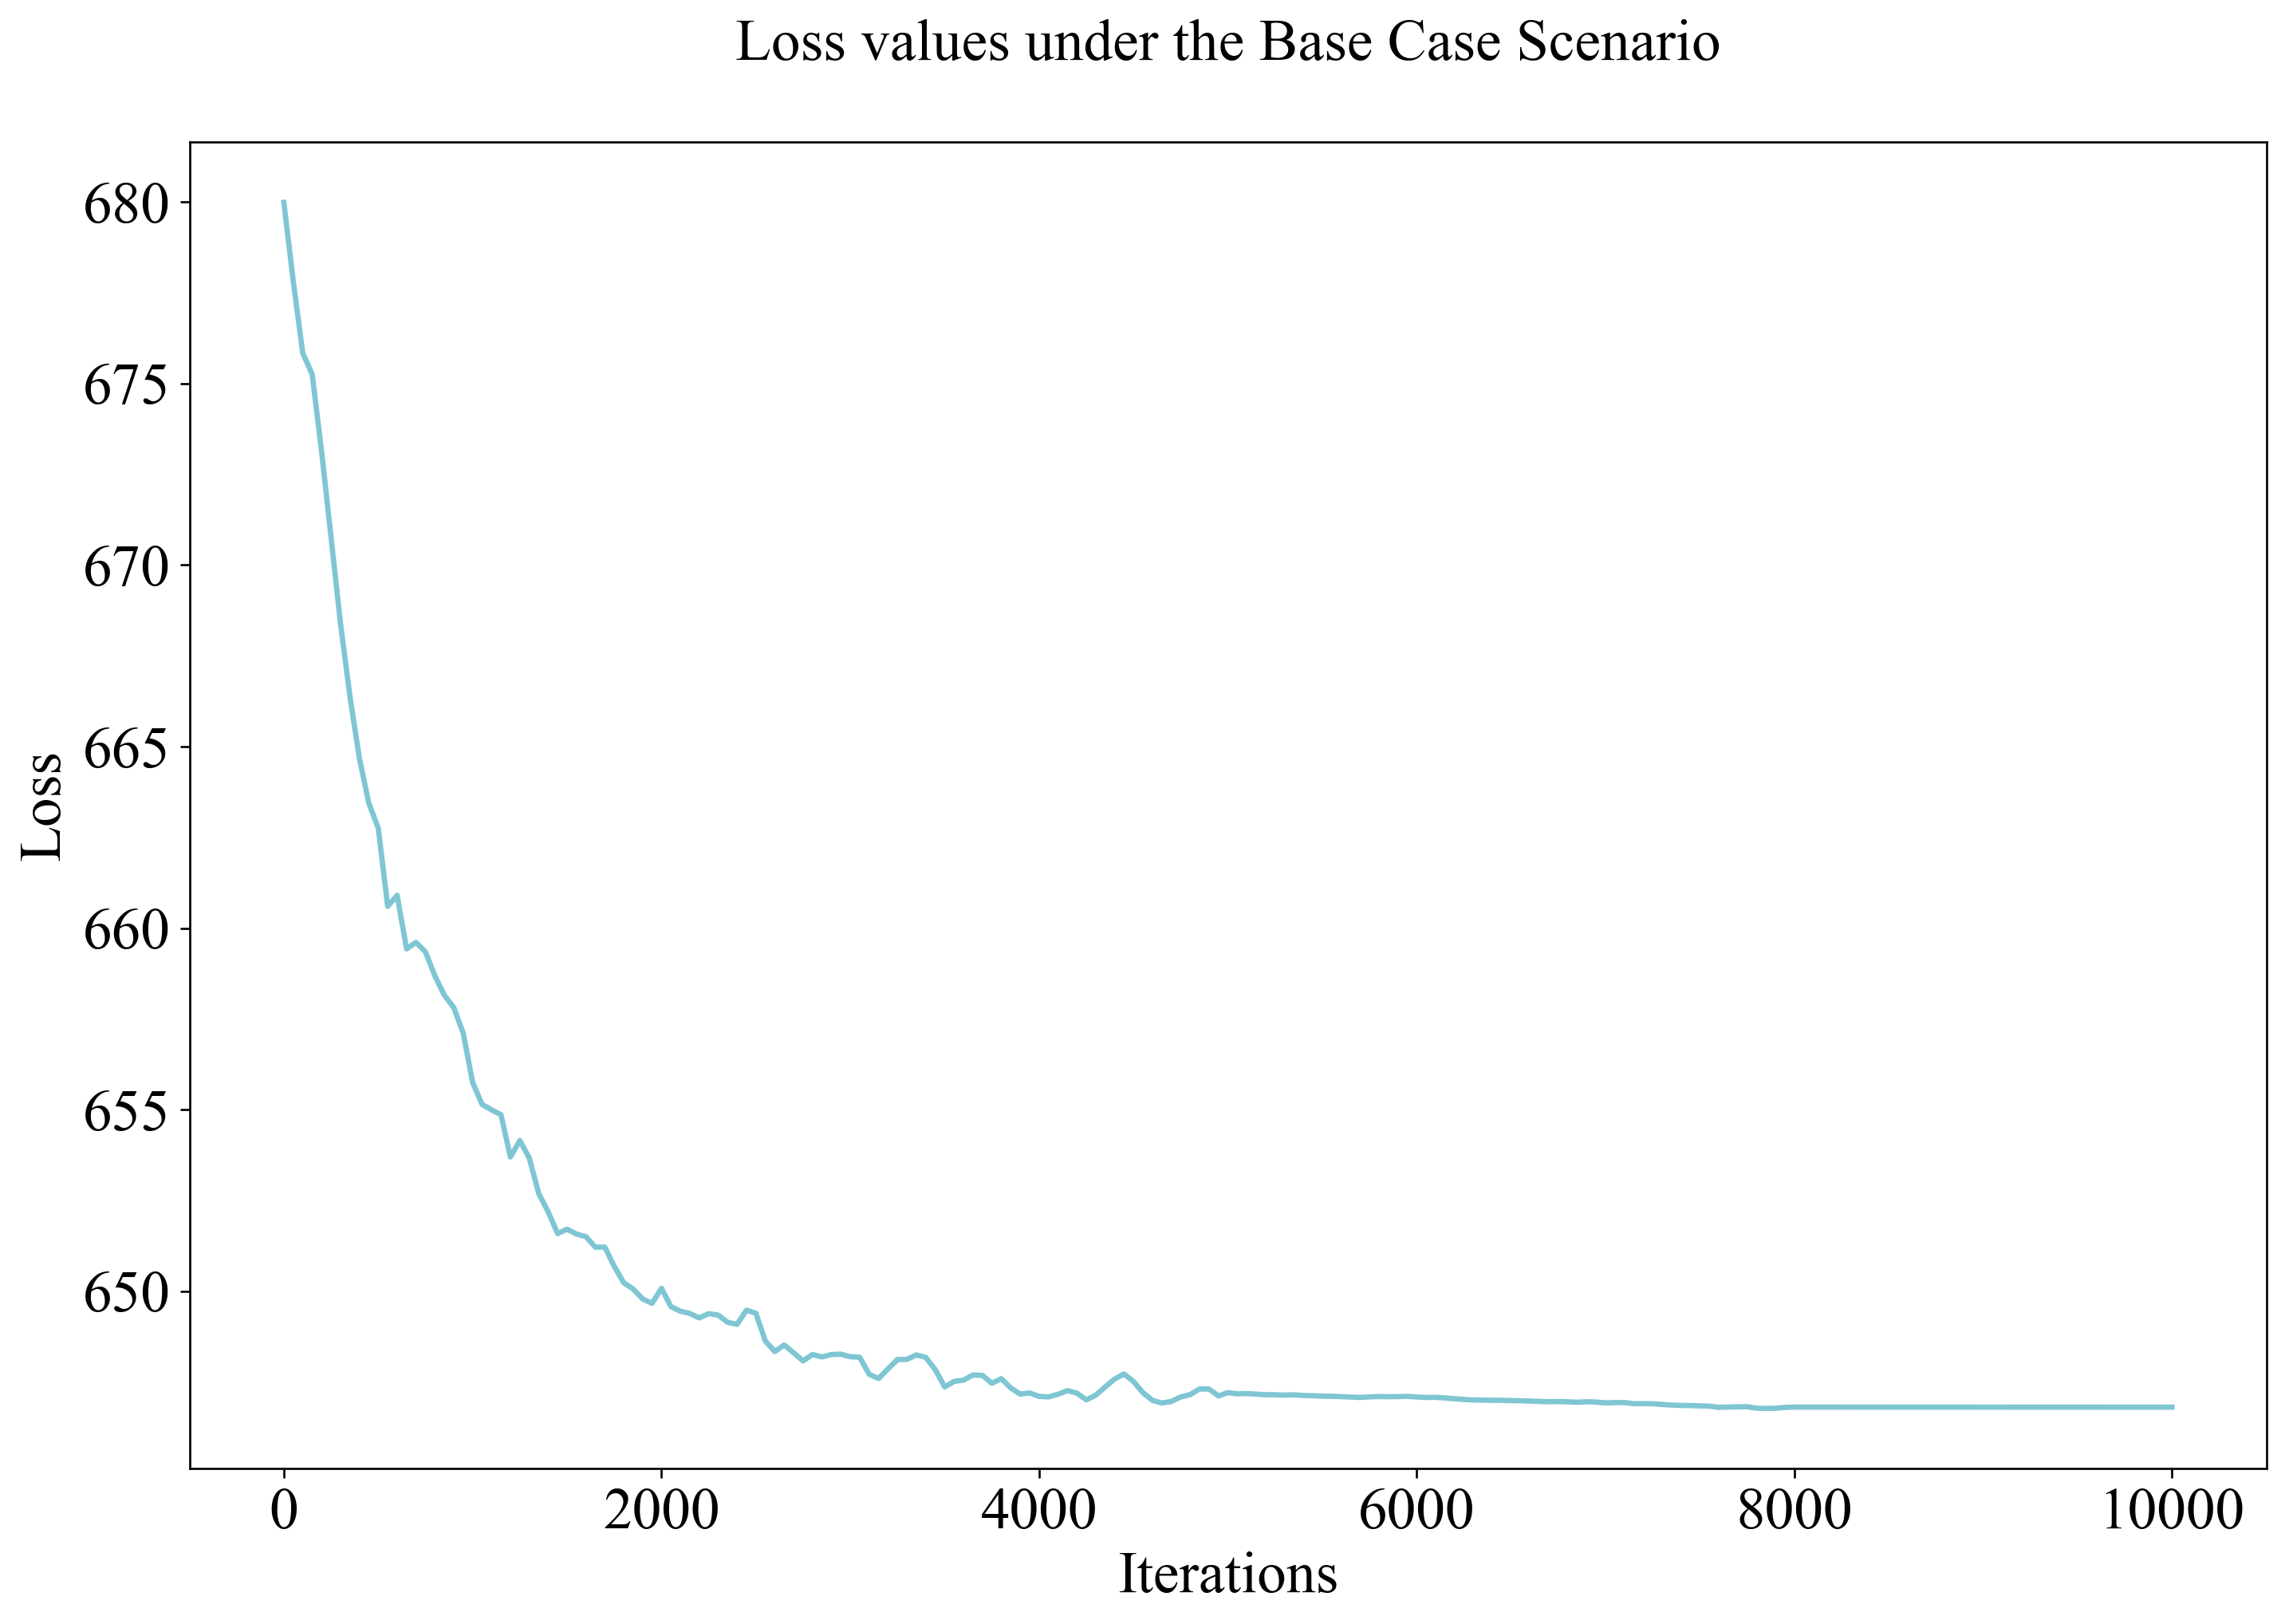

In [22]:
fig2, ax2 = plt.subplots(1, 1,figsize =(14, 9), dpi = 240)
t_axis = np.linspace(0, 10000, len(opt_control_loss))
ax2.plot(t_axis, opt_control_loss, lw = 2, color = new_green)
ax2.set_xlabel('Iterations',fontsize=22, family='Times New Roman')
ax2.set_ylabel('Loss',fontsize=22, family='Times New Roman')
ax2.set_title('Loss values under the Base Case Scenario', fontsize=22,  y=1.05, family='Times New Roman')
ax2.tick_params(axis='both', which='major', labelsize=22)
plt.rc('font', family='Times New Roman')
#plt.savefig('sto_train_loss_'+str(POINTS)+'xpoints_'+str(GRID)+'0%grid_seed'+str(SEED)+'.png')